# Projekat (iz predloga): koaliciona TU igra u mikro-mreži (PV + baterije + pooling)

Ovaj notebook **postavlja i rešava** problem iz predloga projekta:

1) Rešava „solo“ optimizaciju za svaku kuću \(i\):
\[
C^{solo}_i = \min \sum_t ig(c_{buy}(t)\,Import_i(t) - c_{sell}(t)\,Export_i(t)ig)
\]
uz bilans po satu:
\[
Import_i(t) + G_i(t) + Dis_i(t) = L_i(t) + Ch_i(t) + Export_i(t)
\]
i ograničenja baterije/SOC.

2) Rešava koalicioni (pooling) problem za svaku koaliciju \(S\):
\[
C^{coal}_S = \min \sum_t ig(c_{buy}(t)\,Import_S(t) - c_{sell}(t)\,Export_S(t)ig)
\]
gde je koalicija u stanju da interno razmenjuje energiju (idealno bez troška), pa mreža „vidi“ samo agregirani neto bilans.

3) Definiše karakterističnu funkciju (vrednost koalicije kao ušteda):
\[
v(S) = \Big(\sum_{i\in S} C^{solo}_i\Big) - C^{coal}_S
\]

4) Računa raspodele: **Shapley**, **core test**, i **least-core** (min \(
arepsilon\)).

> Napomena: Primer ispod generiše sintetičke profile (24h). U praksi samo zameni `L` i `G` realnim profilima.


## 0) Importi

In [209]:
# !pip -q install numpy pandas matplotlib scipy

import itertools
import math
from typing import Dict, FrozenSet, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog


## 1) Podaci (scenario iz predloga)

- n=5 kuća
- PV: 2 kuće imaju PV
- baterija: 1 kuća ima bateriju
- TOU cene: skuplje veče


In [210]:
np.random.seed(4)

#  osnovni scenario (možeš menjati) 
n = 7
T = 24
hours = np.arange(T)
players = list(range(1, n+1))

# TOU cene (primer)
cbuy = 0.12*np.ones(T)
cbuy[(hours>=18) & (hours<=22)] = 0.22
cbuy[(hours>=7)  & (hours<=9)]  = 0.18
csell = 0.06*np.ones(T)

# Ko ima PV / bateriju (primer: kuće 1 i 3 imaju PV, kuća 2 ima bateriju)
np.random.seed(4)

# verovatnoće posedovanja tehnologije
p_pv = 0.3     # 40% kuća ima PV
p_batt = 0.5  # 30% kuća ima bateriju

has_pv = np.random.rand(n) < p_pv
has_batt = np.random.rand(n) < p_batt

print("Broj kuća sa PV:", has_pv.sum())
print("Broj kuća sa baterijom:", has_batt.sum())

# Parametri baterije (po kući)
E = np.zeros(n)          # kapacitet [kWh]
Pch = np.zeros(n)        # max punjenje [kW] (po satu -> kWh)
Pdis = np.zeros(n)       # max pražnjenje [kW]
eta_ch = 0.95
eta_dis = 0.95

E[has_batt] = 6.0
Pch[has_batt] = 2.0
Pdis[has_batt] = 2.0

SOC0 = 0.5*E  # početni SOC (0 za kuće bez baterije)

#  sintetički profili L_i(t), G_i(t) 
def gaussian(x, mu, sigma):
    return np.exp(-0.5*((x-mu)/sigma)**2)

L = np.zeros((n, T))  # load
G = np.zeros((n, T))  # PV generation

for i in range(n):
    scale_L = np.random.uniform(0.8, 1.4)
    base = 0.35 + 0.08*np.random.randn(T)
    morning = 0.9*gaussian(hours, mu=np.random.uniform(7.0, 8.5), sigma=1.2)
    evening = 1.2*gaussian(hours, mu=np.random.uniform(19.0, 21.0), sigma=1.8)
    L[i] = np.clip(scale_L*(base + morning + evening), 0.05, None)

    if has_pv[i]:
        scale_G = np.random.uniform(0.9, 1.4)
        pv = 1.8*gaussian(hours, mu=np.random.uniform(12.0, 13.5), sigma=2.2)
        G[i] = np.clip(scale_G*pv + 0.02*np.random.randn(T), 0.0, None)
    else:
        G[i] = 0.0

df = pd.DataFrame({"hour": hours, "cbuy": cbuy, "csell": csell})
for i in range(n):
    df[f"L{i+1}"] = L[i]
    df[f"G{i+1}"] = G[i]
df.head()


Broj kuća sa PV: 1
Broj kuća sa baterijom: 4


,hour,cbuy,csell,L1,G1,L2,G2,L3,G3,L4,G4,L5,G5,L6,G6,L7,G7
0,0,0.12,0.06,0.279558,0.0,0.492320,0.0,0.221405,0.0,0.474724,0.0,0.297894,0.0,0.565540,0.000000,0.303539,0.0
1,1,0.12,0.06,0.305735,0.0,0.402962,0.0,0.301474,0.0,0.489753,0.0,0.230928,0.0,0.468168,0.017908,0.293262,0.0
2,2,0.12,0.06,0.308750,0.0,0.312241,0.0,0.189247,0.0,0.491972,0.0,0.236205,0.0,0.480713,0.000000,0.293551,0.0
3,3,0.12,0.06,0.355235,0.0,0.394264,0.0,0.381866,0.0,0.429369,0.0,0.177822,0.0,0.537042,0.000000,0.320174,0.0
4,4,0.12,0.06,0.307507,0.0,0.252270,0.0,0.323667,0.0,0.573312,0.0,0.242327,0.0,0.381959,0.000000,0.312290,0.0


In [211]:
from scipy.optimize import linprog

def _linprog_solve(c, A_eq=None, b_eq=None, A_ub=None, b_ub=None, bounds=None):
    res = linprog(
        c,
        A_ub=A_ub, b_ub=b_ub,
        A_eq=A_eq, b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )
    if not res.success:
        raise RuntimeError("LP failed: " + res.message)
    return res

def solve_solo_schedule(i: int):
    """
    Reši solo LP za domaćinstvo i (1..n) i vrati schedule dict:
    Import, Export, Ch, Dis, SOC (SOC dužine T+1).
    """
    idx = i - 1
    hasB = bool(has_batt[idx])

    # Var order:
    # Import(0..T-1), Export(0..T-1), Ch(0..T-1), Dis(0..T-1), SOC(0..T)
    n_imp = T
    n_exp = T
    n_ch  = T
    n_dis = T
    n_soc = T + 1

    offset_imp = 0
    offset_exp = offset_imp + n_imp
    offset_ch  = offset_exp + n_exp
    offset_dis = offset_ch + n_ch
    offset_soc = offset_dis + n_dis
    nvar = offset_soc + n_soc

    # Objective: sum cbuy*Import - csell*Export
    c = np.zeros(nvar)
    c[offset_imp:offset_imp+T] = cbuy
    c[offset_exp:offset_exp+T] = -csell

    A_eq = []
    b_eq = []

    # Energy balance for each t:
    # Import - Export - Ch + Dis = L - G
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_imp+t] = 1.0
        row[offset_exp+t] = -1.0
        row[offset_ch+t]  = -1.0
        row[offset_dis+t] = 1.0
        A_eq.append(row)
        b_eq.append(L[idx, t] - G[idx, t])

    # SOC dynamics:
    # SOC[t+1] - SOC[t] - eta_ch*Ch[t] + Dis[t]/eta_dis = 0
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_soc+t+1] = 1.0
        row[offset_soc+t]   = -1.0
        row[offset_ch+t]    = -eta_ch
        row[offset_dis+t]   = 1.0/eta_dis
        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(nvar); row[offset_soc+0] = 1.0
    A_eq.append(row); b_eq.append(SOC0[idx])

    # Terminal SOC = initial
    row = np.zeros(nvar); row[offset_soc+T] = 1.0
    A_eq.append(row); b_eq.append(SOC0[idx])

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Bounds
    bounds = []
    bounds += [(0, None)] * T  # Import
    bounds += [(0, None)] * T  # Export

    # Ch, Dis
    for t in range(T):
        bounds.append((0, Pch[idx] if hasB else 0.0))
    for t in range(T):
        bounds.append((0, Pdis[idx] if hasB else 0.0))

    # SOC
    for t in range(T+1):
        bounds.append((0, E[idx] if hasB else 0.0))

    res = _linprog_solve(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)
    x = res.x

    sched = {
        "Import": x[offset_imp:offset_imp+T],
        "Export": x[offset_exp:offset_exp+T],
        "Ch":     x[offset_ch:offset_ch+T],
        "Dis":    x[offset_dis:offset_dis+T],
        "SOC":    x[offset_soc:offset_soc+T+1],
    }
    return sched

#  Izračunaj schedule za svaku kuću 
solo_sched = {}
for i in range(1, n+1):
    solo_sched[i] = solve_solo_schedule(i)

#  Pripremi 3 serije za histogram po kući 
pv_gen = {i: G[i-1].copy() for i in range(1, n+1)}  # ako nema PV već je 0 iz tvoje generacije
batt_balance = {}
grid_import = {}

for i in range(1, n+1):
    sch = solo_sched[i]
    # bilans baterije: + prazni, - puni
    if has_batt[i-1]:
        batt_balance[i] = sch["Dis"] - sch["Ch"]
    else:
        batt_balance[i] = np.zeros(T)
    # uvoz iz mreže
    grid_import[i] = sch["Import"]

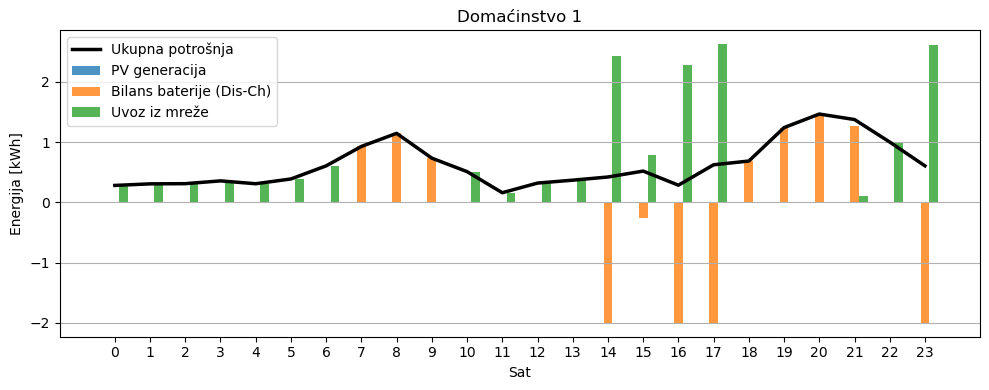

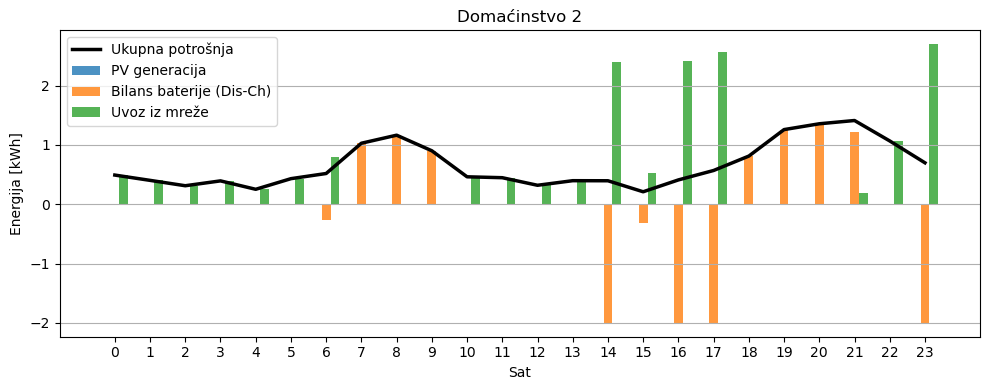

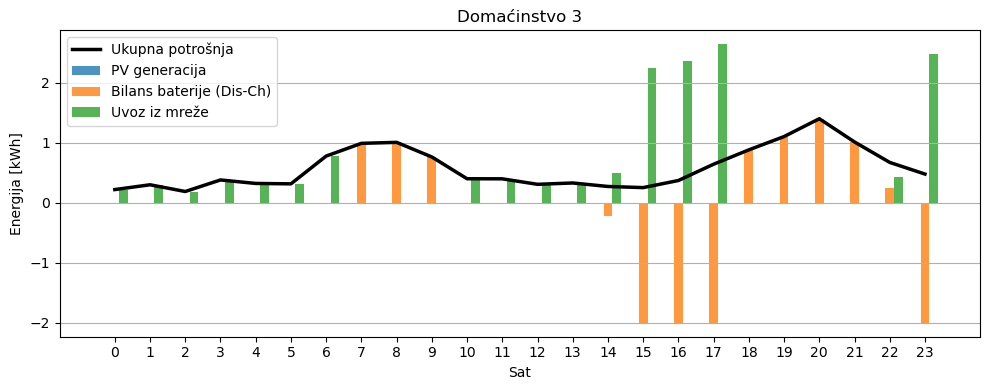

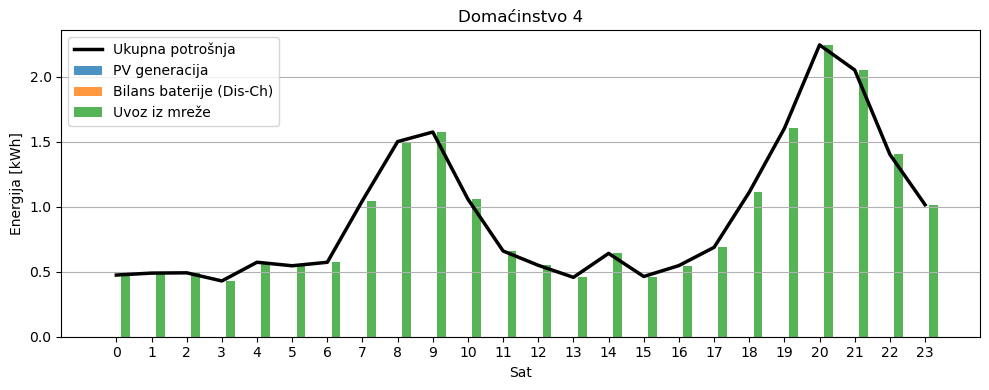

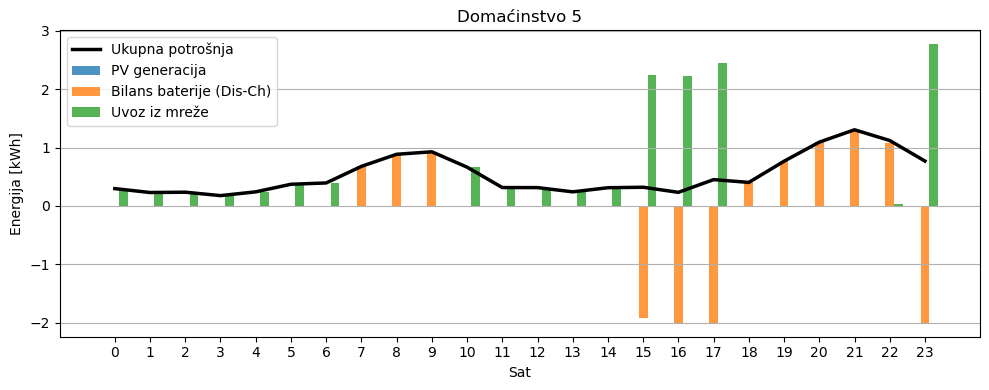

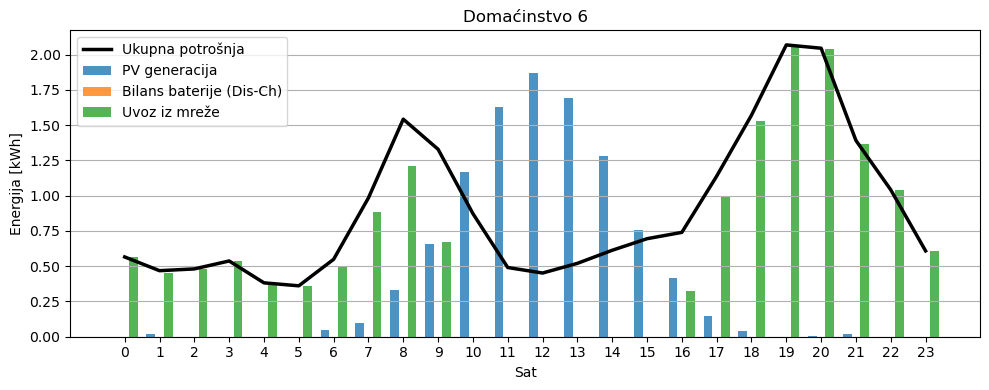

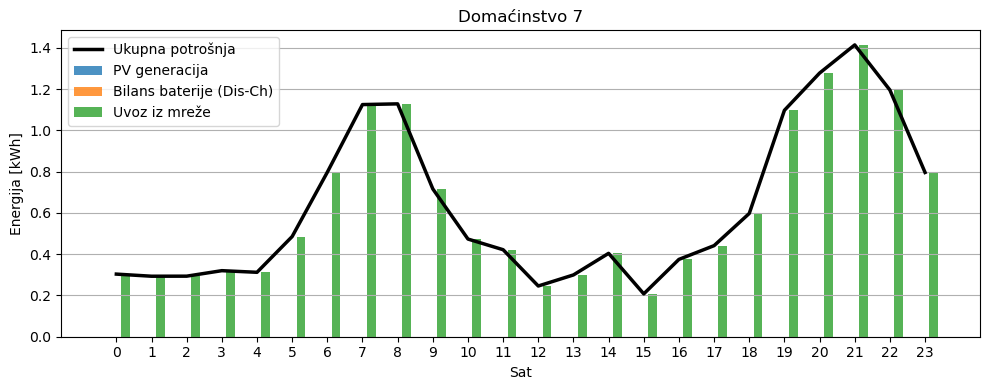

In [212]:
#  Plot: jedan histogram po kući sa tri kategorije + linija potrošnje 
width = 0.25

for i in range(1, n+1):

    pv = pv_gen[i]
    batt = batt_balance[i]
    grid = grid_import[i]

    # ukupna potrošnja domaćinstva
    total_load = L[i-1]

    x = hours

    plt.figure(figsize=(10,4))

    plt.bar(x - width, pv, width=width, label="PV generacija", alpha=0.8)
    plt.bar(x, batt, width=width, label="Bilans baterije (Dis-Ch)", alpha=0.8)
    plt.bar(x + width, grid, width=width, label="Uvoz iz mreže", alpha=0.8)

    # linija ukupne potrošnje
    plt.plot(x, total_load, color="black", linewidth=2.5, label="Ukupna potrošnja")

    plt.title(f"Domaćinstvo {i}")
    plt.xlabel("Sat")
    plt.ylabel("Energija [kWh]")
    plt.xticks(hours)

    plt.legend()
    plt.grid(True, axis="y")

    plt.tight_layout()
    plt.show()

### Grafici profila

## 2) LP modeli

### 2.1 Solo LP (za kuću i)
Varijable po satu: Import, Export, Ch, Dis, SOC.

Bilans: `Import + G + Dis = L + Ch + Export`.
SOC dinamika (korak 1h): `SOC[t+1] = SOC[t] + eta_ch*Ch[t] - Dis[t]/eta_dis`.

### 2.2 Koalicioni LP (pooling)
Baterije su lokalne (svaka kuća upravlja svojom), ali mreža vidi samo agregat:

`Import_S - Export_S = sum_i (L_i - G_i + Ch_i - Dis_i)`

što implementira „idealni pooling“ (viškovi PV jedne kuće mogu da pokriju deficit druge u istom satu).


In [213]:
def _linprog_solve(c, A_eq=None, b_eq=None, A_ub=None, b_ub=None, bounds=None):
    res = linprog(
        c,
        A_ub=A_ub, b_ub=b_ub,
        A_eq=A_eq, b_eq=b_eq,
        bounds=bounds,
        method="highs"
    )
    if not res.success:
        raise RuntimeError("LP failed: " + res.message)
    return res

def solve_solo(i: int) -> Tuple[float, Dict[str, np.ndarray]]:
    """Solo optimization for household i (1..n). Returns (cost, schedule dict)."""
    idx = i-1
    hasB = bool(has_batt[idx])
    T = len(hours)

    # Variable ordering:
    # [Import(0..T-1), Export(0..T-1), Ch(0..T-1), Dis(0..T-1), SOC(0..T-1)]
    # SOC is defined at each hour boundary (T points). We'll store SOC(0..T-1) and add constraints between them.
    # Simpler: SOC at times 0..T-1 and enforce SOC[t+1] using SOC[t] by extending SOC length T (T+1 points).
    # We'll do SOC length T+1.
    n_imp = T
    n_exp = T
    n_ch  = T
    n_dis = T
    n_soc = T+1

    offset_imp = 0
    offset_exp = offset_imp + n_imp
    offset_ch  = offset_exp + n_exp
    offset_dis = offset_ch + n_ch
    offset_soc = offset_dis + n_dis
    nvar = offset_soc + n_soc

    # Objective: sum cbuy*Import - csell*Export
    c = np.zeros(nvar)
    c[offset_imp:offset_imp+T] = cbuy
    c[offset_exp:offset_exp+T] = -csell

    # Equality constraints: energy balance for each t
    A_eq = []
    b_eq = []
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_imp+t] = 1.0
        row[offset_exp+t] = -1.0
        row[offset_ch+t]  = -1.0
        row[offset_dis+t] = 1.0
        # constants: +G -L
        A_eq.append(row)
        b_eq.append(L[idx, t] - G[idx, t])  # move to RHS: Import - Export - Ch + Dis = L - G

    # SOC dynamics for t=0..T-1:
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_soc+t+1] = 1.0
        row[offset_soc+t]   = -1.0
        # SOC[t+1] - SOC[t] - eta_ch*Ch[t] + Dis[t]/eta_dis = 0
        row[offset_ch+t]  = -eta_ch
        row[offset_dis+t] = 1.0/eta_dis
        A_eq.append(row)
        b_eq.append(0.0)

    # Initial SOC
    row = np.zeros(nvar)
    row[offset_soc+0] = 1.0
    A_eq.append(row)
    b_eq.append(SOC0[idx])

    # Terminal SOC = initial (fair comparison); only if has battery (else it's 0 anyway)
    row = np.zeros(nvar)
    row[offset_soc+T] = 1.0
    A_eq.append(row)
    b_eq.append(SOC0[idx])

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Bounds
    bounds = []
    # Import, Export >=0
    bounds += [(0, None)]*T
    bounds += [(0, None)]*T
    # Ch, Dis bounds (0..P)
    for t in range(T):
        bounds.append((0, Pch[idx] if hasB else 0.0))
    for t in range(T):
        bounds.append((0, Pdis[idx] if hasB else 0.0))
    # SOC bounds
    for t in range(T+1):
        bounds.append((0, E[idx] if hasB else 0.0))

    res = _linprog_solve(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)

    x = res.x
    sched = {
        "Import": x[offset_imp:offset_imp+T],
        "Export": x[offset_exp:offset_exp+T],
        "Ch": x[offset_ch:offset_ch+T],
        "Dis": x[offset_dis:offset_dis+T],
        "SOC": x[offset_soc:offset_soc+T+1],
    }
    return float(res.fun), sched

def solve_coalition(S: FrozenSet[int]) -> Tuple[float, Dict[str, np.ndarray]]:
    """Coalition pooling optimization for coalition S. Returns (cost, schedules)."""
    members = sorted(S)
    m = len(members)
    T = len(hours)

    # Vars:
    # ImportS(T), ExportS(T),
    # For each member k: Ch_k(T), Dis_k(T), SOC_k(T+1)
    n_imp = T
    n_exp = T
    n_ch  = m*T
    n_dis = m*T
    n_soc = m*(T+1)

    offset_imp = 0
    offset_exp = offset_imp + n_imp
    offset_ch  = offset_exp + n_exp
    offset_dis = offset_ch + n_ch
    offset_soc = offset_dis + n_dis
    nvar = offset_soc + n_soc

    # Objective: sum cbuy*ImportS - csell*ExportS
    c = np.zeros(nvar)
    c[offset_imp:offset_imp+T] = cbuy
    c[offset_exp:offset_exp+T] = -csell

    A_eq = []
    b_eq = []

    # Aggregated energy balance each t:
    # ImportS - ExportS - sum_k Ch_k + sum_k Dis_k = sum_k (L_k - G_k)
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_imp+t] = 1.0
        row[offset_exp+t] = -1.0

        rhs = 0.0
        for k, i in enumerate(members):
            idx = i-1
            rhs += (L[idx, t] - G[idx, t])
            row[offset_ch + k*T + t]  = -1.0
            row[offset_dis + k*T + t] = 1.0

        A_eq.append(row)
        b_eq.append(rhs)

    # SOC dynamics per member
    for k, i in enumerate(members):
        idx = i-1
        for t in range(T):
            row = np.zeros(nvar)
            soc0 = offset_soc + k*(T+1)
            row[soc0 + t+1] = 1.0
            row[soc0 + t]   = -1.0
            row[offset_ch + k*T + t]  = -eta_ch
            row[offset_dis + k*T + t] = 1.0/eta_dis
            A_eq.append(row)
            b_eq.append(0.0)

        # initial SOC
        row = np.zeros(nvar)
        row[(offset_soc + k*(T+1) + 0)] = 1.0
        A_eq.append(row)
        b_eq.append(SOC0[idx])

        # terminal SOC = initial
        row = np.zeros(nvar)
        row[(offset_soc + k*(T+1) + T)] = 1.0
        A_eq.append(row)
        b_eq.append(SOC0[idx])

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # Bounds
    bounds = []
    bounds += [(0, None)]*T  # ImportS
    bounds += [(0, None)]*T  # ExportS

    # ✅ Prvo SVI Ch blokovi (po istom redu kao varijable)
    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        bounds += [(0, Pch[idx] if hasB else 0.0)]*T

    # ✅ Onda SVI Dis blokovi
    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        bounds += [(0, Pdis[idx] if hasB else 0.0)]*T

    # ✅ Na kraju SOC blokovi
    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        bounds += [(0, E[idx] if hasB else 0.0)]*(T+1)

    res = _linprog_solve(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds)

    x = res.x
    sched = {
        "ImportS": x[offset_imp:offset_imp+T],
        "ExportS": x[offset_exp:offset_exp+T],
    }
    # per member schedules
    for k, i in enumerate(members):
        sched[f"Ch{i}"]  = x[offset_ch + k*T : offset_ch + (k+1)*T]
        sched[f"Dis{i}"] = x[offset_dis + k*T: offset_dis + (k+1)*T]
        soc0 = offset_soc + k*(T+1)
        sched[f"SOC{i}"] = x[soc0: soc0+T+1]

    return float(res.fun), sched


## 3) Solo i koalicioni troškovi + karakteristična funkcija v(S)

In [214]:
# Solo troškovi
C_solo = {}
solo_sched = {}
for i in players:
    c, sch = solve_solo(i)
    C_solo[i] = c
    solo_sched[i] = sch

C_solo


{1: 1.9964861524954718,
 2: 2.1130486022585315,
 3: 1.7982927621361489,
 4: 3.754326058544235,
 5: 1.6276139884142042,
 6: 2.607511457468906,
 7: 2.5395673535382812}

In [215]:
def powerset(players: List[int]) -> List[FrozenSet[int]]:
    out = []
    n = len(players)
    for r in range(1, n+1):
        for comb in itertools.combinations(players, r):
            out.append(frozenset(comb))
    return out

coalitions = powerset(players)

# Koalicioni troškovi
C_coal = {}
for S in coalitions:
    c, _ = solve_coalition(S)
    C_coal[S] = c

# v(S) = sum_{i in S} C_solo_i - C_coal_S
v = {}
for S in coalitions:
    v[S] = sum(C_solo[i] for i in S) - C_coal[S]

vN = v[frozenset(players)]
print("v(N) (ukupna usteda velike koalicije) =", vN)


v(N) (ukupna usteda velike koalicije) = 0.747541465343831


In [216]:
# tabela koalicija
def coalition_str(S: FrozenSet[int]) -> str:
    return "{" + ",".join(map(str, sorted(S))) + "}"

df_v = pd.DataFrame([{
    "S": coalition_str(S),
    "|S|": len(S),
    "C_coal(S)": C_coal[S],
    "sum C_solo": sum(C_solo[i] for i in S),
    "v(S) = savings": v[S]
} for S in sorted(coalitions, key=lambda s: (len(s), sorted(s)))])
df_v


,S,|S|,C_coal(S),sum C_solo,v(S) = savings
0,{1},1,1.996486,1.996486,0.000000
1,{2},1,2.113049,2.113049,0.000000
2,{3},1,1.798293,1.798293,0.000000
3,{4},1,3.754326,3.754326,0.000000
4,{5},1,1.627614,1.627614,0.000000
...,...,...,...,...,...
122,"{1,2,3,5,6,7}",6,12.126816,12.682520,0.555704
123,"{1,2,4,5,6,7}",6,13.943311,14.638554,0.695243
124,"{1,3,4,5,6,7}",6,13.615532,14.323798,0.708266
125,"{2,3,4,5,6,7}",6,13.743385,14.440360,0.696976


In [217]:
import numpy as np

def build_coalition_lp_matrices(S: FrozenSet[int]):
    members = sorted(S)
    m = len(members)
    T = len(hours)

    # Vars: ImportS(T), ExportS(T), Ch_k(m*T), Dis_k(m*T), SOC_k(m*(T+1))
    n_imp = T
    n_exp = T
    n_ch  = m*T
    n_dis = m*T
    n_soc = m*(T+1)

    offset_imp = 0
    offset_exp = offset_imp + n_imp
    offset_ch  = offset_exp + n_exp
    offset_dis = offset_ch + n_ch
    offset_soc = offset_dis + n_dis
    nvar = offset_soc + n_soc

    # A_eq x = b_eq
    A_eq = []
    b_eq = []

    # Aggregated energy balance each t:
    # ImportS - ExportS - sum Ch + sum Dis = sum(L - G)
    for t in range(T):
        row = np.zeros(nvar)
        row[offset_imp+t] = 1.0
        row[offset_exp+t] = -1.0

        rhs = 0.0
        for k, i in enumerate(members):
            idx = i-1
            rhs += (L[idx, t] - G[idx, t])
            row[offset_ch + k*T + t]  = -1.0
            row[offset_dis + k*T + t] = 1.0

        A_eq.append(row)
        b_eq.append(rhs)

    # SOC dynamics per member:
    for k, i in enumerate(members):
        idx = i-1
        soc0 = offset_soc + k*(T+1)

        for t in range(T):
            row = np.zeros(nvar)
            row[soc0 + t+1] = 1.0
            row[soc0 + t]   = -1.0
            row[offset_ch + k*T + t]  = -eta_ch
            row[offset_dis + k*T + t] = 1.0/eta_dis
            A_eq.append(row)
            b_eq.append(0.0)

        # initial SOC
        row = np.zeros(nvar)
        row[soc0 + 0] = 1.0
        A_eq.append(row)
        b_eq.append(SOC0[idx])

        # terminal SOC = initial
        row = np.zeros(nvar)
        row[soc0 + T] = 1.0
        A_eq.append(row)
        b_eq.append(SOC0[idx])

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

   # bounds in the same order as variables:
    bounds = []
    bounds += [(0, None)]*T  # ImportS
    bounds += [(0, None)]*T  # ExportS

    # ✅ prvo svi Ch blokovi
    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        bounds += [(0, Pch[idx] if hasB else 0.0)]*T

    # ✅ onda svi Dis blokovi
    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        bounds += [(0, Pdis[idx] if hasB else 0.0)]*T

    # ✅ pa SOC blokovi
    for k, i in enumerate(members):
        idx = i-1
        hasB = bool(has_batt[idx])
        bounds += [(0, E[idx] if hasB else 0.0)]*(T+1)

    return members, (offset_imp, offset_exp, offset_ch, offset_dis, offset_soc, nvar), A_eq, b_eq, bounds

#  GRAND COALITION 
S = frozenset(players)
members, offs, A_eq, b_eq, bounds = build_coalition_lp_matrices(S)
offset_imp, offset_exp, offset_ch, offset_dis, offset_soc, nvar = offs

# kandidat: "summed solo schedule"
Import_sum = np.sum([solo_sched[i]["Import"] for i in players], axis=0)
Export_sum = np.sum([solo_sched[i]["Export"] for i in players], axis=0)

x_cand = np.zeros(nvar)
T = len(hours)

# ImportS, ExportS
x_cand[offset_imp:offset_imp+T] = Import_sum
x_cand[offset_exp:offset_exp+T] = Export_sum

# Ch/Dis/SOC per member
for k, i in enumerate(members):
    x_cand[offset_ch + k*T : offset_ch + (k+1)*T] = solo_sched[i]["Ch"]
    x_cand[offset_dis + k*T : offset_dis + (k+1)*T] = solo_sched[i]["Dis"]
    soc0 = offset_soc + k*(T+1)
    x_cand[soc0 : soc0+T+1] = solo_sched[i]["SOC"]

# 1) proveri bounds
viol_bounds = []
for j, (lo, hi) in enumerate(bounds):
    if lo is not None and x_cand[j] < lo - 1e-8:
        viol_bounds.append(("LOW", j, x_cand[j], lo))
    if hi is not None and x_cand[j] > hi + 1e-8:
        viol_bounds.append(("HIGH", j, x_cand[j], hi))

print("Bounds violations:", len(viol_bounds))
if viol_bounds[:5]:
    print("First few:", viol_bounds[:5])

# 2) proveri jednakosti
resid = A_eq @ x_cand - b_eq
print("Max |A_eq x - b_eq| =", np.max(np.abs(resid)))
print("Mean |resid| =", np.mean(np.abs(resid)))

# 3) ako je feasible, uporedi ciljnu funkciju (trošak)
cost_cand = float(np.sum(cbuy*Import_sum - csell*Export_sum))
print("Candidate cost (summed solo) =", cost_cand)

Bounds violations: 0
Max |A_eq x - b_eq| = 1.7763568394002505e-15
Mean |resid| = 3.018082008689746e-17
Candidate cost (summed solo) = 16.43684637485578


In [218]:
#  SOLO vs KOALICIJA: ukupno i po domaćinstvu (uz pravilo raspodele) 

N = frozenset(players)

# 1) ukupni troškovi
C_solo_sum = sum(C_solo.values())
C_N = C_coal[N]
vN = C_solo_sum - C_N

print("Sum solo costs =", C_solo_sum)
print("Coalition cost =", C_N)
print("v(N) savings   =", vN)

# 2) Shapley raspodela uštede
def shapley_value(players, v):
    n = len(players)
    phi = {i: 0.0 for i in players}
    fact = math.factorial(n)

    for pi in itertools.permutations(players):
        S = frozenset()
        for i in pi:
            before = S
            after = frozenset(set(S) | {i})
            v_before = v.get(before, 0.0)     # v(empty)=0
            v_after = v[after]
            phi[i] += (v_after - v_before)
            S = after

    for i in players:
        phi[i] /= fact
    return phi

phi = shapley_value(players, v)  # x_i = ušteda dodeljena i-tom

# 3) Equal split raspodela uštede
x_eq = {i: vN/len(players) for i in players}

# 4) računi/bilansi u koaliciji (po pravilu raspodele)
bill_shapley = {i: C_solo[i] - phi[i] for i in players}
bill_eq      = {i: C_solo[i] - x_eq[i] for i in players}

# 5) tabela
df_costs = pd.DataFrame({
    "House": players,
    "Solo cost [€]": [C_solo[i] for i in players],
    "Coal bill (Shapley) [€]": [bill_shapley[i] for i in players],
    "Coal bill (Equal split) [€]": [bill_eq[i] for i in players],
    "Savings (Shapley) x_i [€]": [phi[i] for i in players],
    "Savings (Equal split) [€]": [x_eq[i] for i in players],
})

df_costs.loc["TOTAL"] = [
    "—",
    df_costs["Solo cost [€]"].sum(),
    df_costs["Coal bill (Shapley) [€]"].sum(),
    df_costs["Coal bill (Equal split) [€]"].sum(),
    df_costs["Savings (Shapley) x_i [€]"].sum(),
    df_costs["Savings (Equal split) [€]"].sum(),
]

df_costs

Sum solo costs = 16.43684637485578
Coalition cost = 15.689304909511948
v(N) savings   = 0.747541465343831


,House,Solo cost [€],Coal bill (Shapley) [€],Coal bill (Equal split) [€],Savings (Shapley) x_i [€],Savings (Equal split) [€]
0,1,1.996486,1.937624,1.889695,0.058862,0.106792
1,2,2.113049,2.059579,2.006257,0.053470,0.106792
2,3,1.798293,1.738231,1.691501,0.060061,0.106792
3,4,3.754326,3.638744,3.647534,0.115582,0.106792
4,5,1.627614,1.561552,1.520822,0.066062,0.106792
5,6,2.607511,2.296856,2.500720,0.310655,0.106792
6,7,2.539567,2.456719,2.432776,0.082848,0.106792
TOTAL,—,16.436846,15.689305,15.689305,0.747541,0.747541


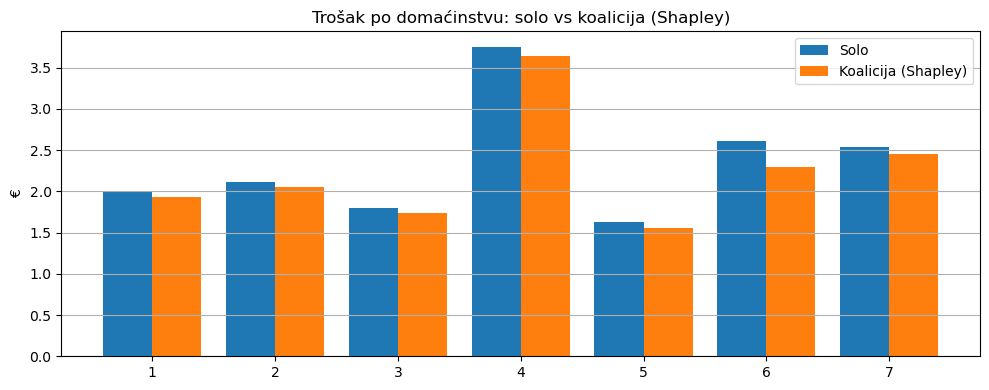

In [219]:
x = np.arange(len(players))
plt.figure(figsize=(10,4))
plt.bar(x-0.2, [C_solo[i] for i in players], width=0.4, label="Solo")
plt.bar(x+0.2, [bill_shapley[i] for i in players], width=0.4, label="Koalicija (Shapley)")

plt.xticks(x, [str(i) for i in players])
plt.ylabel("€")
plt.title("Trošak po domaćinstvu: solo vs koalicija (Shapley)")
plt.grid(True, axis="y")
plt.legend()
plt.tight_layout()
plt.show()

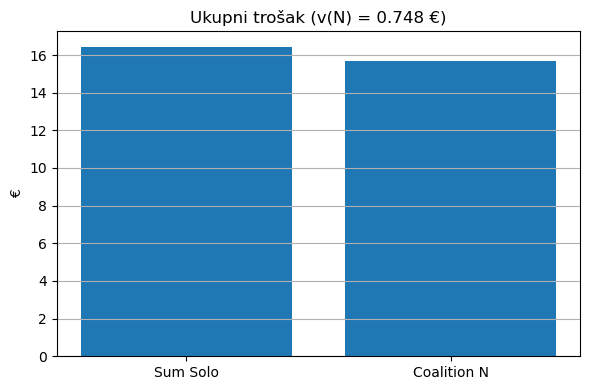

In [220]:
plt.figure(figsize=(6,4))
plt.bar(["Sum Solo", "Coalition N"], [C_solo_sum, C_N])
plt.ylabel("€")
plt.title(f"Ukupni trošak (v(N) = {vN:.3f} €)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

In [221]:
import numpy as np
import pandas as pd
import itertools, math
import matplotlib.pyplot as plt

# Shapley za "sub-igru" definisanu na S: koristi v(T) za sve T ⊆ S
def shapley_on_subset(S, v):
    members = sorted(S)
    m = len(members)
    phi = {i: 0.0 for i in members}
    fact = math.factorial(m)

    for pi in itertools.permutations(members):
        T = frozenset()
        for i in pi:
            before = T
            after = frozenset(set(T) | {i})
            v_before = v.get(before, 0.0)   # v(∅)=0
            v_after = v[after]
            phi[i] += (v_after - v_before)
            T = after

    for i in members:
        phi[i] /= fact
    return phi  # ušteda x_i(S) za i∈S

# Lista koalicija (pretpostavljam da već imaš coalitions i v iz prethodnih ćelija)
coalitions_sorted = sorted(coalitions, key=lambda s: (len(s), sorted(s)))

# Matrica ΔC: redovi koalicije, kolone domaćinstva
# ΔC_i(S) = bill_i(S) - C_solo[i] = - x_i(S)  (negativno => jeftinije)
M = np.zeros((len(coalitions_sorted), n))

coal_labels = []
for r, S in enumerate(coalitions_sorted):
    coal_labels.append("{" + ",".join(map(str, sorted(S))) + "}")
    phiS = shapley_on_subset(S, v)  # x_i(S)
    for i in players:
        if i in S:
            M[r, i-1] = -phiS[i]   # minus = jeftinije (tvoja konvencija)
        else:
            M[r, i-1] = 0.0

df_M = pd.DataFrame(M, index=coal_labels, columns=[f"H{i}" for i in players])

# Prikaži tabelu (može biti dugačka za 31 koaliciju)
df_M.head(10)

,H1,H2,H3,H4,H5,H6,H7
{1},-0.000000e+00,0.0,0.000000e+00,0.000000,0.0,0.0,0.0
{2},0.000000e+00,-0.0,0.000000e+00,0.000000,0.0,0.0,0.0
{3},0.000000e+00,0.0,-0.000000e+00,0.000000,0.0,0.0,0.0
{4},0.000000e+00,0.0,0.000000e+00,-0.000000,0.0,0.0,0.0
{5},0.000000e+00,0.0,0.000000e+00,0.000000,-0.0,0.0,0.0
{6},0.000000e+00,0.0,0.000000e+00,0.000000,0.0,-0.0,0.0
{7},0.000000e+00,0.0,0.000000e+00,0.000000,0.0,0.0,-0.0
"{1,2}",-0.000000e+00,-0.0,0.000000e+00,0.000000,0.0,0.0,0.0
"{1,3}",-2.220446e-16,0.0,-2.220446e-16,0.000000,0.0,0.0,0.0
"{1,4}",-6.813847e-02,0.0,0.000000e+00,-0.068138,0.0,0.0,0.0


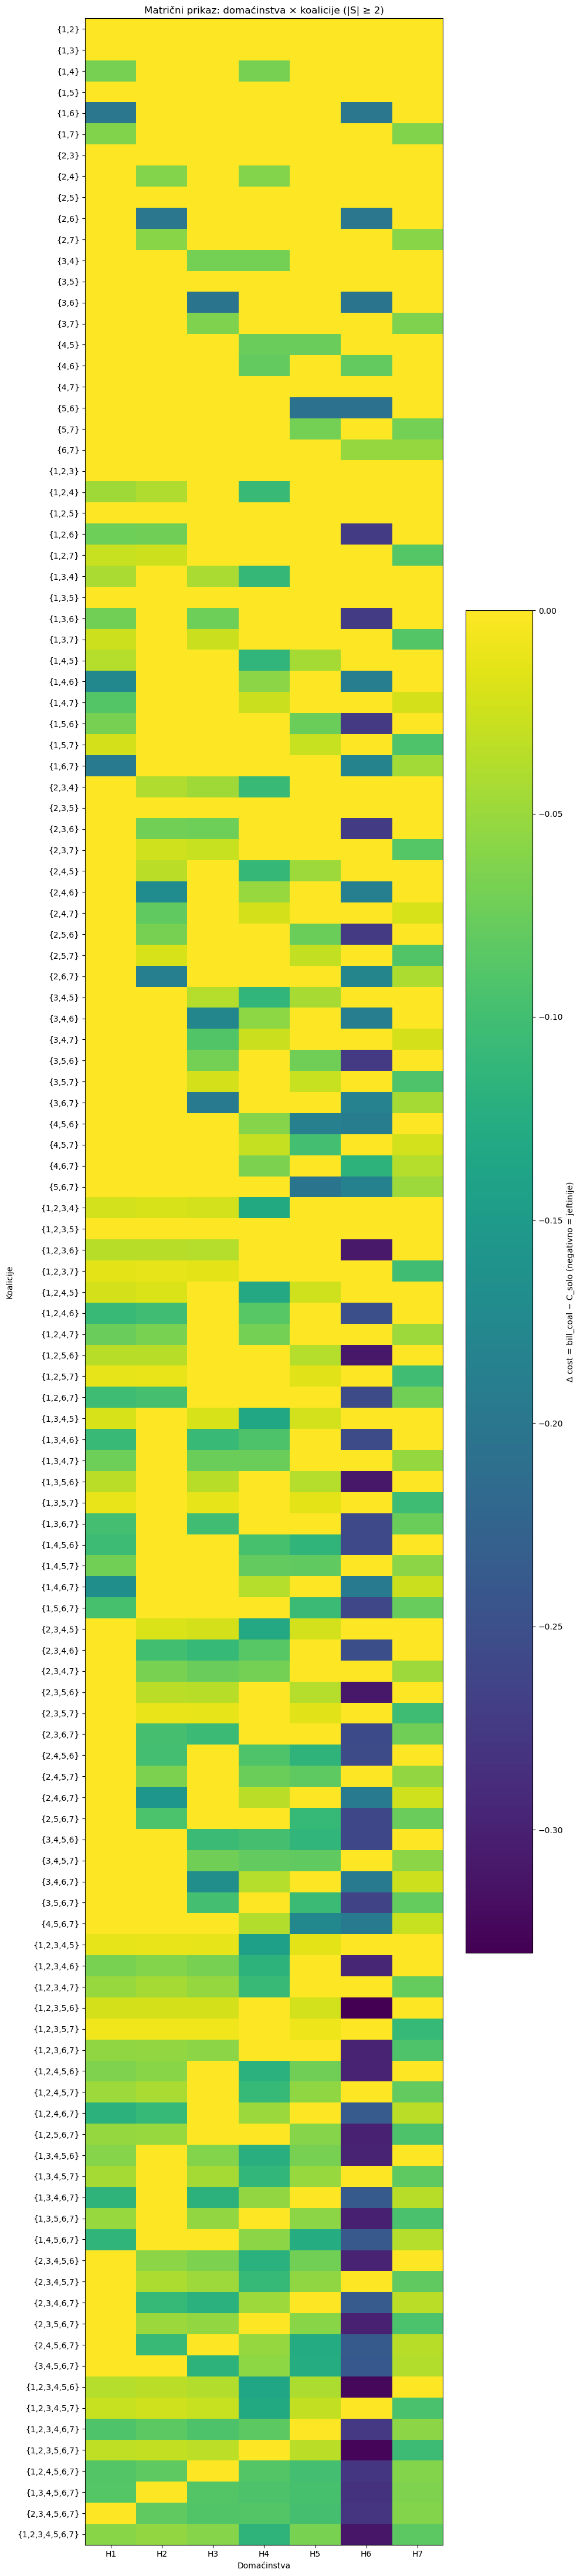

In [222]:
# filtriraj koalicije sa 2 ili više članova
coalitions_k = [S for S in coalitions_sorted if len(S) >= 2]

# uzmi indekse tih koalicija
idx = [coalitions_sorted.index(S) for S in coalitions_k]

# filtrirana matrica i oznake
M_k = df_M.values[idx, :]
labels_k = ["{" + ",".join(map(str, sorted(S))) + "}" for S in coalitions_k]

plt.figure(figsize=(10, 0.35*len(coalitions_k) + 2))

im = plt.imshow(M_k, aspect="auto")
plt.colorbar(im, label="Δ cost = bill_coal − C_solo (negativno = jeftinije)")

plt.xticks(np.arange(n), [f"H{i}" for i in players])
plt.yticks(np.arange(len(coalitions_k)), labels_k)

plt.title("Matrični prikaz: domaćinstva × koalicije (|S| ≥ 2)")
plt.xlabel("Domaćinstva")
plt.ylabel("Koalicije")

plt.tight_layout()
plt.show()

In [223]:
import itertools, math
import numpy as np
import pandas as pd

#  Shapley ušteda unutar koalicije S (sub-igra) 
def shapley_on_subset(S, v):
    members = sorted(S)
    m = len(members)
    phi = {i: 0.0 for i in members}
    fact = math.factorial(m)

    for pi in itertools.permutations(members):
        T = frozenset()
        for i in pi:
            before = T
            after = frozenset(set(T) | {i})
            v_before = v.get(before, 0.0)   # v(∅)=0
            v_after = v[after]
            phi[i] += (v_after - v_before)
            T = after

    for i in members:
        phi[i] /= fact
    return phi  # ušteda x_i(S)

#  Generisanje svih particija skupa (set partitions) 
def partitions(lst):
    """Generiše sve particije liste lst. Vraća listu blokova (svaki blok je tuple)."""
    if not lst:
        yield []
        return
    first = lst[0]
    for rest in partitions(lst[1:]):
        # stavi 'first' kao novi blok
        yield [(first,)] + rest
        # ubaci 'first' u neki od postojećih blokova
        for i in range(len(rest)):
            yield rest[:i] + [tuple(sorted(rest[i] + (first,)))] + rest[i+1:]

def canonical_partition(part):
    """Sortira blokove i elemente radi kanonskog prikaza i deduplikacije."""
    blocks = [tuple(sorted(b)) for b in part]
    blocks.sort(key=lambda b: (len(b), b))
    return tuple(blocks)

#  Precompute x_i(S) za sve koalicije S 
all_coalitions = []
for r in range(1, len(players)+1):
    for comb in itertools.combinations(players, r):
        all_coalitions.append(frozenset(comb))

x_shapley = {}  # x_shapley[S][i] = ušteda igrača i u koaliciji S
for S in all_coalitions:
    x_shapley[S] = shapley_on_subset(S, v)

def find_block(partition, i):
    for b in partition:
        if i in b:
            return b
    raise ValueError("player not found")

def partition_value(partition):
    # ukupna "socijalna" ušteda particije (pretpostavka: koalicije su nezavisne)
    return sum(v[frozenset(b)] for b in partition)

def payoff_in_partition(partition, i):
    b = find_block(partition, i)
    S = frozenset(b)
    return x_shapley[S][i]  # ušteda (veće je bolje)

def is_nash_stable(partition):
    """Nash-stabilno: niko ne može jednostrano da pređe u drugi blok ili da bude sam i poveća uštedu."""
    blocks = [tuple(b) for b in partition]
    for i in players:
        current = payoff_in_partition(blocks, i)
        b_i = find_block(blocks, i)

        # opcija 1: postani sam (singleton)
        if (i,) != b_i:
            alt_partition = [b for b in blocks if b != b_i]
            b_i_minus = tuple(x for x in b_i if x != i)
            if len(b_i_minus) > 0:
                alt_partition.append(b_i_minus)
            alt_partition.append((i,))
            alt = payoff_in_partition(alt_partition, i)
            if alt > current + 1e-9:
                return False

        # opcija 2: pridruži se nekom drugom bloku
        for b in blocks:
            if b == b_i:
                continue
            # formiraj novu particiju gde i prelazi iz b_i u b
            alt_partition = [blk for blk in blocks if blk not in (b_i, b)]
            b_i_minus = tuple(x for x in b_i if x != i)
            if len(b_i_minus) > 0:
                alt_partition.append(b_i_minus)
            b_plus = tuple(sorted(b + (i,)))
            alt_partition.append(b_plus)

            # izračunaj novu uštedu i
            alt = payoff_in_partition(alt_partition, i)
            if alt > current + 1e-9:
                return False

    return True

#  Enumeriši sve particije i nađi Nash-stabilne 
parts = set()
for p in partitions(players):
    parts.add(canonical_partition(p))
parts = [list(p) for p in sorted(parts, key=lambda P: (len(P), P))]

stable_parts = []
for P in parts:
    if is_nash_stable(P):
        stable_parts.append(P)

print("Ukupno particija:", len(parts))
print("Nash-stabilnih particija:", len(stable_parts))

# tabela stabilnih particija
rows = []
for P in stable_parts:
    Pi = [frozenset(b) for b in P]
    rows.append({
        "Partition": " | ".join("{" + ",".join(map(str,b)) + "}" for b in P),
        "k blocks": len(P),
        "Total savings Σ v(S)": partition_value(P),
    })
df_stable = pd.DataFrame(rows).sort_values("Total savings Σ v(S)", ascending=False)
df_stable

Ukupno particija: 877
Nash-stabilnih particija: 4


,Partition,k blocks,Total savings Σ v(S)
3,"{5,7} | {1,2,3,4,6}",2,0.747541
0,"{1,2,3,4,5,6,7}",1,0.747541
2,"{3,7} | {1,2,4,5,6}",2,0.737783
1,"{1,7} | {2,3,4,5,6}",2,0.734504


In [224]:
best = stable_parts[np.argmax([partition_value(P) for P in stable_parts])] if stable_parts else None
print("BEST Nash-stable partition:", " | ".join("{" + ",".join(map(str,b)) + "}" for b in best) if best else "nema")
print("Total savings:", partition_value(best) if best else None)

# I prikaži uštede po kućama u toj particiji
if best:
    bills = []
    for i in players:
        bills.append({"House": i, "Savings x_i": payoff_in_partition(best, i)})
    display(pd.DataFrame(bills))

BEST Nash-stable partition: {5,7} | {1,2,3,4,6}
Total savings: 0.7475414653438355


,House,Savings x_i
0,1,0.066811
1,2,0.060972
2,3,0.068062
3,4,0.117254
4,5,0.069530
5,6,0.295382
6,7,0.069530


## 5) Core test + blokirajuće koalicije

In [225]:
def core_violations(players: List[int], v: Dict[FrozenSet[int], float], x: Dict[int, float]):
    viol = []
    for S in powerset(players):
        lhs = sum(x[i] for i in S)
        rhs = v[S]
        deficit = rhs - lhs  # >0 znači kršenje core uslova
        if deficit > 1e-9:
            viol.append((S, lhs, rhs, deficit))
    viol.sort(key=lambda t: t[3], reverse=True)
    return viol

viol_shapley = core_violations(players, v, phi)
print("Broj core-kršenja (Shapley):", len(viol_shapley))
if viol_shapley:
    S, lhs, rhs, deficit = viol_shapley[0]
    print("Najgore kršenje:", coalition_str(S), "deficit =", deficit)


Broj core-kršenja (Shapley): 23
Najgore kršenje: {3,6} deficit = 0.03480810896728004


In [226]:
df_viol = pd.DataFrame([{
    "S": coalition_str(S),
    "sum x_i": lhs,
    "v(S)": rhs,
    "deficit": deficit
} for (S, lhs, rhs, deficit) in viol_shapley[:10]])
df_viol


,S,sum x_i,v(S),deficit
0,"{3,6}",0.370717,0.405525,0.034808
1,"{5,6}",0.376718,0.411318,0.034600
2,"{2,6}",0.364125,0.398174,0.034048
3,"{1,6}",0.369517,0.399170,0.029653
4,"{3,5,6,7}",0.519628,0.544585,0.024957
5,"{2,5,6,7}",0.513036,0.537234,0.024198
6,"{2,3,6,7}",0.507035,0.529842,0.022807
7,"{3,4,5,6}",0.552361,0.574512,0.022151
8,"{1,4,5,6}",0.551162,0.572779,0.021617
9,"{1,3,6,7}",0.512427,0.532437,0.020010


In [227]:
print("v(N) =", v[frozenset(players)])

v(N) = 0.747541465343831


,S,|S|,sum x_i,v(S),deficit = v(S) - sum x_i
0,"{3,6}",2,0.370717,0.405525,0.034808
1,"{5,6}",2,0.376718,0.411318,0.034600
2,"{2,6}",2,0.364125,0.398174,0.034048
3,"{1,6}",2,0.369517,0.399170,0.029653
4,"{3,5,6,7}",4,0.519628,0.544585,0.024957
5,"{2,5,6,7}",4,0.513036,0.537234,0.024198
6,"{2,3,6,7}",4,0.507035,0.529842,0.022807
7,"{3,4,5,6}",4,0.552361,0.574512,0.022151
8,"{1,4,5,6}",4,0.551162,0.572779,0.021617
9,"{1,3,6,7}",4,0.512427,0.532437,0.020010


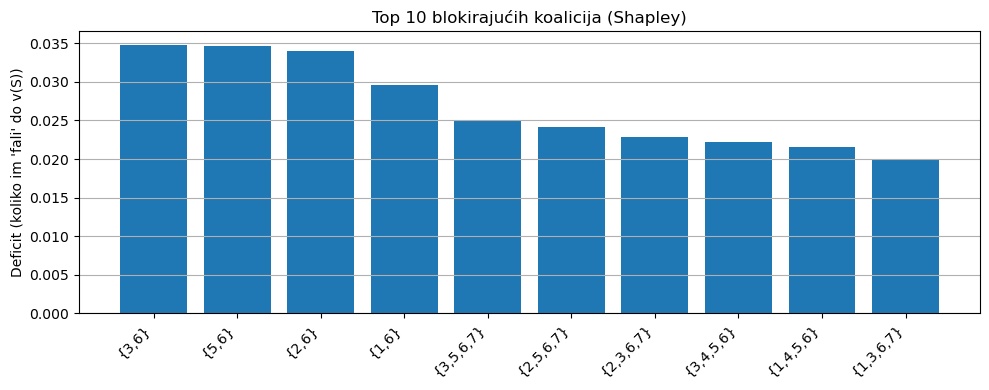

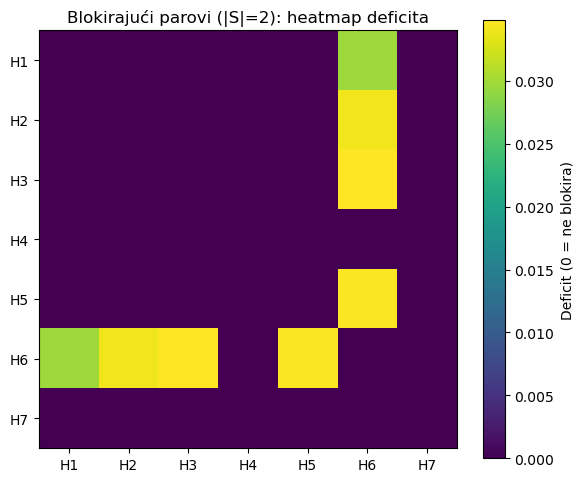

In [228]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# - 1) TOP blokirajuće koalicije (po deficitu) -
K = 10  # koliko da prikažeš

if len(viol_shapley) == 0:
    print("Nema blokirajućih koalicija: Shapley je u core-u (stabilno).")
else:
    top = viol_shapley[:K]
    df_top = pd.DataFrame([{
        "S": coalition_str(S),
        "|S|": len(S),
        "sum x_i": lhs,
        "v(S)": rhs,
        "deficit = v(S) - sum x_i": deficit
    } for (S, lhs, rhs, deficit) in top])

    display(df_top)

    plt.figure(figsize=(10,4))
    plt.bar(df_top["S"], df_top["deficit = v(S) - sum x_i"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Deficit (koliko im 'fali' do v(S))")
    plt.title(f"Top {min(K, len(df_top))} blokirajućih koalicija (Shapley)")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()


# - 2) HEATMAP za blokiranje parova (koalicije veličine 2) -
# U matricu stavljamo deficit za par {i,j} (0 ako ne blokira)
n = len(players)
pair_def = np.zeros((n, n))

# napravi dict radi lakšeg pristupa: deficit po koaliciji
deficit_map = {S: deficit for (S, lhs, rhs, deficit) in viol_shapley}

for a in players:
    for b in players:
        if a >= b:
            continue
        S = frozenset({a, b})
        d = deficit_map.get(S, 0.0)
        pair_def[a-1, b-1] = d
        pair_def[b-1, a-1] = d  # simetrično

plt.figure(figsize=(6,5))
im = plt.imshow(pair_def, aspect="equal")
plt.colorbar(im, label="Deficit (0 = ne blokira)")
plt.xticks(np.arange(n), [f"H{i}" for i in players])
plt.yticks(np.arange(n), [f"H{i}" for i in players])
plt.title("Blokirajući parovi (|S|=2): heatmap deficita")
plt.tight_layout()
plt.show()

## 6) Least core (min ε) kao LP

In [229]:
def least_core(players: List[int], v: Dict[FrozenSet[int], float]):
    n = len(players)
    coalitions = powerset(players)

    # variables: x1..xn, eps
    c = np.zeros(n+1)
    c[-1] = 1.0  # minimize eps

    A_ub = []
    b_ub = []

    # sum_{i in S} x_i + eps >= v(S)  <=>  -sum x_i - eps <= -v(S)
    for S in coalitions:
        row = np.zeros(n+1)
        for i in S:
            row[i-1] = -1.0
        row[-1] = -1.0
        A_ub.append(row)
        b_ub.append(-v[S])

    A_ub = np.array(A_ub)
    b_ub = np.array(b_ub)

    # efficiency: sum x_i = v(N)
    A_eq = np.zeros((1, n+1))
    A_eq[0, :n] = 1.0
    b_eq = np.array([v[frozenset(players)]])

    # ✅ KLJUČNO: x_i može biti i negativan; eps >= 0
    bounds = [(None, None)]*n + [(0, None)]

    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(res.message)

    x = {players[i]: float(res.x[i]) for i in range(n)}
    eps = float(res.x[-1])
    return x, eps

In [230]:
x_lc, eps_lc = least_core(players, v)
print("eps* =", eps_lc)
print("x_lc =", x_lc)
print("sum(x_lc) =", sum(x_lc.values()), " v(N) =", v[frozenset(players)])

eps* = 0.0
x_lc = {1: 0.012676929262890546, 2: 0.02326679393416775, 3: 0.019031351435919497, 4: 0.16701274628084573, 5: 0.02482474278500657, 6: 0.386493410150079, 7: 0.11423549149492196}
sum(x_lc) = 0.747541465343831  v(N) = 0.747541465343831


In [231]:
df_compare = pd.DataFrame({
    "player": players,
    "Shapley": [phi[i] for i in players],
    "Least-core": [x_lc[i] for i in players],
})
df_compare


,player,Shapley,Least-core
0,1,0.058862,0.012677
1,2,0.053470,0.023267
2,3,0.060061,0.019031
3,4,0.115582,0.167013
4,5,0.066062,0.024825
5,6,0.310655,0.386493
6,7,0.082848,0.114235


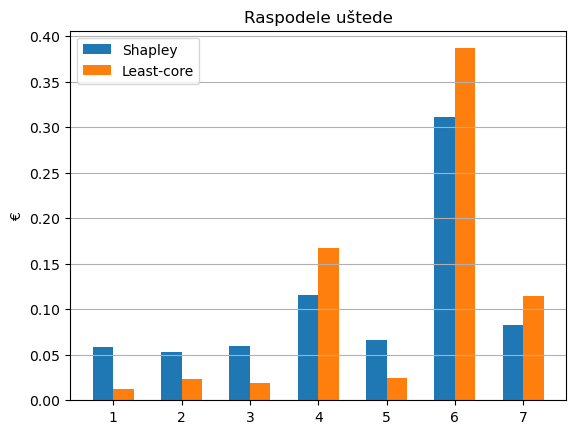

In [232]:
plt.figure()
xpos = np.arange(n)
plt.bar(xpos-0.15, df_compare["Shapley"], width=0.3, label="Shapley")
plt.bar(xpos+0.15, df_compare["Least-core"], width=0.3, label="Least-core")
plt.xticks(xpos, [str(i) for i in players])
plt.ylabel("€")
plt.title("Raspodele uštede")
plt.grid(True, axis="y")
plt.legend()
plt.show()


## 7) Dve heuristike (iz predloga): equal split, proportional PV

In [233]:
def equal_split(players: List[int], vN: float) -> Dict[int, float]:
    return {i: vN/len(players) for i in players}

def proportional_pv(players: List[int], vN: float, G: np.ndarray) -> Dict[int, float]:
    totals = np.array([G[i-1].sum() for i in players], dtype=float)
    if totals.sum() <= 1e-12:
        return equal_split(players, vN)
    shares = totals / totals.sum()
    return {players[k]: float(vN*shares[k]) for k in range(len(players))}

def summarize_allocation(name: str, x: Dict[int, float]):
    viol = core_violations(players, v, x)
    worst = viol[0][3] if viol else 0.0
    print(f"{name}: core violations = {len(viol)}, worst deficit = {worst:.6f}")

x_eq = equal_split(players, vN)
x_pv = proportional_pv(players, vN, G)

summarize_allocation("Equal split", x_eq)
summarize_allocation("Prop PV", x_pv)


Equal split: core violations = 49, worst deficit = 0.197735
Prop PV: core violations = 45, worst deficit = 0.333801


## 8) Dinamicko prosirenje

In [235]:
# =========================
# DINAMIČKO PROŠIRENJE: parametri
# =========================

from scipy.optimize import linprog
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# koliko sati unapred gleda MPC optimizacija
H_MPC = 6

# male penalizacije da spreče "degenerisana" kruženja energije
EPS_IMPORT_EXPORT = 1e-6
EPS_SHARE = 1e-6
EPS_BATT = 1e-6

# opciono: trošak interne razmene i degradacije baterije
share_penalty = 0.0
battery_penalty = 0.0

# ako želiš da na kraju dana baterija ostane blizu početnog SOC
terminal_soc_weight = 1e-3

In [239]:
# =========================
# STANJE SISTEMA I IZBOR KOALICIJA
# =========================

def get_state(t, soc):
    """
    Globalno stanje sistema u trenutku t.
    """
    return {
        "t": t,
        "L": L[:, t].copy(),
        "G": G[:, t].copy(),
        "SOC": soc.copy(),
        "cbuy": cbuy[t],
        "csell": csell[t]
    }

def coalition_str(S):
    return "{" + ",".join(map(str, sorted(S))) + "}"

def sample_coalitions(players, max_size=4, random_count=100, seed=4):
    """
    Za veliki n ne računamo sve koalicije.
    Uzimamo:
    - sve jednočlane
    - sve parove
    - slučajan uzorak trojki/četvorki
    - veliku koaliciju
    """
    rng = np.random.default_rng(seed)
    P = list(players)
    C = set()

    # singletons
    for i in P:
        C.add(frozenset({i}))

    # svi parovi
    for comb in itertools.combinations(P, 2):
        C.add(frozenset(comb))

    # uzorak trojki i četvorki
    for k in range(3, min(max_size, len(P)) + 1):
        all_k = list(itertools.combinations(P, k))
        if len(all_k) <= random_count:
            for comb in all_k:
                C.add(frozenset(comb))
        else:
            idx = rng.choice(len(all_k), size=random_count, replace=False)
            for j in idx:
                C.add(frozenset(all_k[j]))

    # velika koalicija
    C.add(frozenset(P))

    return sorted(C, key=lambda s: (len(s), tuple(sorted(s))))

# ako je n malo, možeš i sve koalicije
if n <= 10:
    dyn_coalitions = []
    for r in range(1, n+1):
        for comb in itertools.combinations(players, r):
            dyn_coalitions.append(frozenset(comb))
else:
    dyn_coalitions = sample_coalitions(players, max_size=4, random_count=120, seed=4)

print("Broj koalicija za dinamičku analizu:", len(dyn_coalitions))

Broj koalicija za dinamičku analizu: 127


In [240]:
# =========================
# DINAMIČKI KOALICIONI MPC LP
# =========================

def solve_dynamic_mpc_for_coalition(S, t0, soc_now, H=4,
                                    share_penalty=0.0,
                                    battery_penalty=0.0,
                                    terminal_soc_weight=1e-4):
    """
    Rešava MPC LP za koaliciju S od sata t0 na horizontu H.
    
    Varijable po članu i po satu:
    Import, Export, Ch, Dis, ShareOut, ShareIn, SOC
    """
    members = sorted(S)
    m = len(members)

    t1 = min(T, t0 + H)
    tau = list(range(t0, t1))
    Hh = len(tau)

    # po članu:
    # [Import(Hh), Export(Hh), Ch(Hh), Dis(Hh), ShareOut(Hh), ShareIn(Hh), SOC(Hh+1)]
    block_u = 6 * Hh
    block_soc = Hh + 1
    block_total = block_u + block_soc

    base = {i: k * block_total for k, i in enumerate(members)}
    nvar = m * block_total

    def idx_imp(i, h):  return base[i] + 0*Hh + h
    def idx_exp(i, h):  return base[i] + 1*Hh + h
    def idx_ch(i, h):   return base[i] + 2*Hh + h
    def idx_dis(i, h):  return base[i] + 3*Hh + h
    def idx_sout(i, h): return base[i] + 4*Hh + h
    def idx_sin(i, h):  return base[i] + 5*Hh + h
    def idx_soc(i, h):  return base[i] + block_u + h  # h = 0..Hh

    # ciljna funkcija
    c = np.zeros(nvar)

    for i in members:
        ii = i - 1
        for h, t in enumerate(tau):
            c[idx_imp(i, h)]  = cbuy[t] + EPS_IMPORT_EXPORT
            c[idx_exp(i, h)]  = -csell[t] + EPS_IMPORT_EXPORT
            c[idx_sout(i, h)] = share_penalty + EPS_SHARE
            c[idx_sin(i, h)]  = share_penalty + EPS_SHARE
            c[idx_ch(i, h)]   = battery_penalty + EPS_BATT
            c[idx_dis(i, h)]  = battery_penalty + EPS_BATT

        # blaga terminalna penalizacija
        if has_batt[ii]:
            c[idx_soc(i, Hh)] += terminal_soc_weight

    A_eq = []
    b_eq = []

    # 1) lokalni bilans:
    # Import + G + Dis + ShareIn = L + Ch + Export + ShareOut
    for i in members:
        ii = i - 1
        for h, t in enumerate(tau):
            row = np.zeros(nvar)
            row[idx_imp(i, h)]  = 1.0
            row[idx_dis(i, h)]  = 1.0
            row[idx_sin(i, h)]  = 1.0
            row[idx_ch(i, h)]   = -1.0
            row[idx_exp(i, h)]  = -1.0
            row[idx_sout(i, h)] = -1.0
            A_eq.append(row)
            b_eq.append(L[ii, t] - G[ii, t])

    # 2) interna razmena mora da se balansira
    for h in range(Hh):
        row = np.zeros(nvar)
        for i in members:
            row[idx_sout(i, h)] = 1.0
            row[idx_sin(i, h)] = -1.0
        A_eq.append(row)
        b_eq.append(0.0)

    # 3) dinamika baterije
    for i in members:
        ii = i - 1
        for h in range(Hh):
            row = np.zeros(nvar)
            row[idx_soc(i, h+1)] = 1.0
            row[idx_soc(i, h)]   = -1.0
            row[idx_ch(i, h)]    = -eta_ch
            row[idx_dis(i, h)]   = 1.0 / eta_dis
            A_eq.append(row)
            b_eq.append(0.0)

        # početni SOC
        row = np.zeros(nvar)
        row[idx_soc(i, 0)] = 1.0
        A_eq.append(row)
        b_eq.append(float(soc_now[i]))

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)

    # granice
    bounds = [(0, None)] * nvar

    for i in members:
        ii = i - 1
        hasB = bool(has_batt[ii])

        for h in range(Hh):
            bounds[idx_ch(i, h)] = (0, Pch[ii] if hasB else 0.0)
            bounds[idx_dis(i, h)] = (0, Pdis[ii] if hasB else 0.0)

            # singleton nema internu razmenu
            if len(members) == 1:
                bounds[idx_sout(i, h)] = (0, 0.0)
                bounds[idx_sin(i, h)] = (0, 0.0)

        for h in range(Hh + 1):
            bounds[idx_soc(i, h)] = (0, E[ii] if hasB else 0.0)

    res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"MPC LP failed for coalition {coalition_str(S)} at t={t0}: {res.message}")

    x = res.x

    out = {"members": members, "tau": tau}

    for i in members:
        out[f"Import_{i}"] = np.array([x[idx_imp(i, h)] for h in range(Hh)])
        out[f"Export_{i}"] = np.array([x[idx_exp(i, h)] for h in range(Hh)])
        out[f"Ch_{i}"] = np.array([x[idx_ch(i, h)] for h in range(Hh)])
        out[f"Dis_{i}"] = np.array([x[idx_dis(i, h)] for h in range(Hh)])
        out[f"ShareOut_{i}"] = np.array([x[idx_sout(i, h)] for h in range(Hh)])
        out[f"ShareIn_{i}"] = np.array([x[idx_sin(i, h)] for h in range(Hh)])
        out[f"SOC_{i}"] = np.array([x[idx_soc(i, h)] for h in range(Hh + 1)])

    return float(res.fun), out

In [241]:
# =========================
# SIMULACIJA PARTICIJE KORAK-PO-KORAK
# =========================

def simulate_partition_dynamic(partition, H=4,
                               share_penalty=0.0,
                               battery_penalty=0.0,
                               terminal_soc_weight=1e-4):
    """
    partition = lista disjunktnih koalicija, npr.
    [frozenset({1}), frozenset({2,4}), frozenset({3,5})]
    """
    soc = {i: float(SOC0[i-1]) for i in players}

    logs = {
        i: {
            "Import": np.zeros(T),
            "Export": np.zeros(T),
            "Ch": np.zeros(T),
            "Dis": np.zeros(T),
            "ShareOut": np.zeros(T),
            "ShareIn": np.zeros(T),
            "SOC": np.zeros(T+1),
            "Cost": np.zeros(T)
        }
        for i in players
    }

    for i in players:
        logs[i]["SOC"][0] = soc[i]

    for t in range(T):
        _state = get_state(t, soc)

        for S in partition:
            _, plan = solve_dynamic_mpc_for_coalition(
                S=S,
                t0=t,
                soc_now={i: soc[i] for i in S},
                H=H,
                share_penalty=share_penalty,
                battery_penalty=battery_penalty,
                terminal_soc_weight=terminal_soc_weight
            )

            # primeni samo prvi korak MPC plana
            for i in S:
                imp = float(plan[f"Import_{i}"][0])
                exp = float(plan[f"Export_{i}"][0])
                ch = float(plan[f"Ch_{i}"][0])
                dis = float(plan[f"Dis_{i}"][0])
                sout = float(plan[f"ShareOut_{i}"][0])
                sin = float(plan[f"ShareIn_{i}"][0])

                logs[i]["Import"][t] = imp
                logs[i]["Export"][t] = exp
                logs[i]["Ch"][t] = ch
                logs[i]["Dis"][t] = dis
                logs[i]["ShareOut"][t] = sout
                logs[i]["ShareIn"][t] = sin

                logs[i]["Cost"][t] = cbuy[t] * imp - csell[t] * exp

                soc_next = soc[i] + eta_ch * ch - dis / eta_dis
                soc[i] = float(np.clip(soc_next, 0, E[i-1] if has_batt[i-1] else 0.0))
                logs[i]["SOC"][t+1] = soc[i]

    cost_per_house = {i: float(np.sum(logs[i]["Cost"])) for i in players}
    total_cost = float(sum(cost_per_house.values()))

    return {
        "partition": partition,
        "logs": logs,
        "cost_per_house": cost_per_house,
        "total_cost": total_cost
    }

In [242]:
# =========================
# DINAMIČKI SOLO vs GRAND COALITION
# =========================

solo_partition = [frozenset({i}) for i in players]
grand_partition = [frozenset(players)]

solo_dyn = simulate_partition_dynamic(
    partition=solo_partition,
    H=H_MPC,
    share_penalty=share_penalty,
    battery_penalty=battery_penalty,
    terminal_soc_weight=terminal_soc_weight
)

grand_dyn = simulate_partition_dynamic(
    partition=grand_partition,
    H=H_MPC,
    share_penalty=share_penalty,
    battery_penalty=battery_penalty,
    terminal_soc_weight=terminal_soc_weight
)

C_solo_dyn = solo_dyn["cost_per_house"]
C_solo_dyn_sum = sum(C_solo_dyn.values())

C_grand_dyn = grand_dyn["total_cost"]
vN_dyn = C_solo_dyn_sum - C_grand_dyn

print("Dinamički solo zbir:", C_solo_dyn_sum)
print("Dinamički trošak velike koalicije:", C_grand_dyn)
print("Dinamička ušteda v(N):", vN_dyn)

Dinamički solo zbir: 15.338893572441371
Dinamički trošak velike koalicije: 13.970028663730632
Dinamička ušteda v(N): 1.368864908710739


In [244]:
# =========================
# DINAMIČKE METRIKE
# =========================

def compute_dynamic_metrics(sim_result):
    logs = sim_result["logs"]

    total_import = 0.0
    total_export = 0.0
    total_pv = float(np.sum(G))
    total_load = float(np.sum(L))

    import_profile = np.zeros(T)

    for i in players:
        total_import += np.sum(logs[i]["Import"])
        total_export += np.sum(logs[i]["Export"])
        import_profile += logs[i]["Import"]

    peak_import = float(np.max(import_profile))
    self_consumed_pv = total_pv - total_export
    self_consumption_ratio = 100.0 * self_consumed_pv / total_pv if total_pv > 1e-12 else np.nan

    return {
        "total_import": total_import,
        "total_export": total_export,
        "peak_import": peak_import,
        "total_pv": total_pv,
        "total_load": total_load,
        "self_consumption_%": self_consumption_ratio
    }

metrics_solo_dyn = compute_dynamic_metrics(solo_dyn)
metrics_grand_dyn = compute_dynamic_metrics(grand_dyn)

df_metrics_dyn = pd.DataFrame({
    "Metric": [
        "Total cost [€]",
        "Peak import [kWh/h]",
        "Self-consumption PV [%]",
        "Total import [kWh]",
        "Total export [kWh]"
    ],
    "Solo": [
        C_solo_dyn_sum,
        metrics_solo_dyn["peak_import"],
        metrics_solo_dyn["self_consumption_%"],
        metrics_solo_dyn["total_import"],
        metrics_solo_dyn["total_export"]
    ],
    "Grand coalition": [
        C_grand_dyn,
        metrics_grand_dyn["peak_import"],
        metrics_grand_dyn["self_consumption_%"],
        metrics_grand_dyn["total_import"],
        metrics_grand_dyn["total_export"]
    ]
})

df_metrics_dyn["Improvement"] = [
    df_metrics_dyn.loc[0, "Solo"] - df_metrics_dyn.loc[0, "Grand coalition"],
    df_metrics_dyn.loc[1, "Solo"] - df_metrics_dyn.loc[1, "Grand coalition"],
    df_metrics_dyn.loc[2, "Grand coalition"] - df_metrics_dyn.loc[2, "Solo"],
    df_metrics_dyn.loc[3, "Solo"] - df_metrics_dyn.loc[3, "Grand coalition"],
    df_metrics_dyn.loc[4, "Solo"] - df_metrics_dyn.loc[4, "Grand coalition"],
]

df_metrics_dyn

,Metric,Solo,Grand coalition,Improvement
0,Total cost [€],15.338894,13.970029,1.368865
1,Peak import [kWh/h],12.411026,12.411026,0.000000
2,Self-consumption PV [%],53.263524,100.000000,46.736476
3,Total import [kWh],101.028601,98.202659,2.825943
4,Total export [kWh],4.759908,0.000000,4.759908


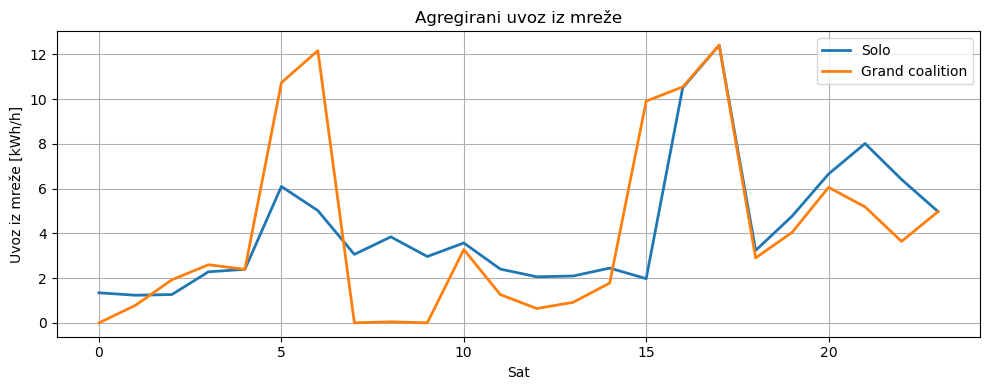

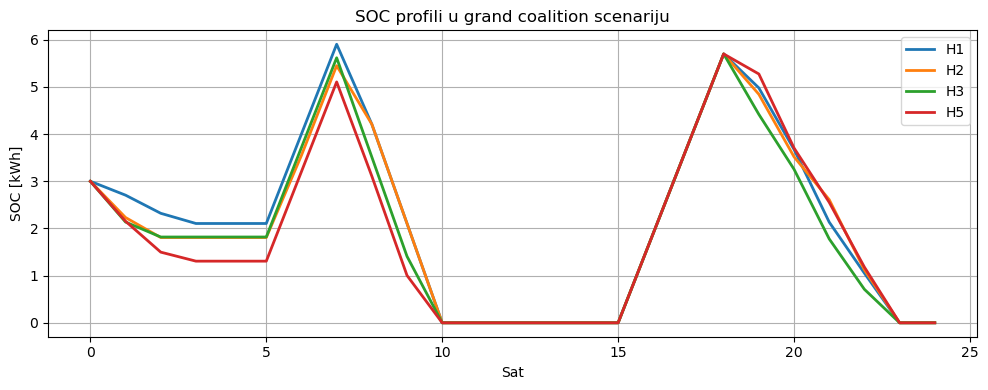

In [245]:
# =========================
# GRAFICI DINAMIČKOG RADA
# =========================

# agregirani import profili
import_solo_profile = np.zeros(T)
import_grand_profile = np.zeros(T)

for i in players:
    import_solo_profile += solo_dyn["logs"][i]["Import"]
    import_grand_profile += grand_dyn["logs"][i]["Import"]

plt.figure(figsize=(10,4))
plt.plot(hours, import_solo_profile, linewidth=2, label="Solo")
plt.plot(hours, import_grand_profile, linewidth=2, label="Grand coalition")
plt.xlabel("Sat")
plt.ylabel("Uvoz iz mreže [kWh/h]")
plt.title("Agregirani uvoz iz mreže")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# SOC za kuće sa baterijom
houses_with_batt = [i for i in players if has_batt[i-1]]

if len(houses_with_batt) > 0:
    plt.figure(figsize=(10,4))
    for i in houses_with_batt[:min(6, len(houses_with_batt))]:
        plt.plot(np.arange(T+1), grand_dyn["logs"][i]["SOC"], linewidth=2, label=f"H{i}")
    plt.xlabel("Sat")
    plt.ylabel("SOC [kWh]")
    plt.title("SOC profili u grand coalition scenariju")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [246]:
# =========================
# DINAMIČKA KARAKTERISTIČNA FUNKCIJA v_dyn(S)
# =========================

C_coal_dyn = {}
v_dyn = {}

for S in dyn_coalitions:
    simS = simulate_partition_dynamic(
        partition=[S],
        H=H_MPC,
        share_penalty=share_penalty,
        battery_penalty=battery_penalty,
        terminal_soc_weight=terminal_soc_weight
    )

    C_coal_dyn[S] = simS["total_cost"]
    v_dyn[S] = sum(C_solo_dyn[i] for i in S) - C_coal_dyn[S]

df_v_dyn = pd.DataFrame({
    "Coalition": [coalition_str(S) for S in dyn_coalitions],
    "Size": [len(S) for S in dyn_coalitions],
    "C_coal_dyn [€]": [C_coal_dyn[S] for S in dyn_coalitions],
    "Sum solo [€]": [sum(C_solo_dyn[i] for i in S) for S in dyn_coalitions],
    "v_dyn(S) [€]": [v_dyn[S] for S in dyn_coalitions]
}).sort_values(["Size", "v_dyn(S) [€]"], ascending=[True, False])

df_v_dyn.head(20)

,Coalition,Size,C_coal_dyn [€],Sum solo [€],v_dyn(S) [€]
0,{1},1,1.720082,1.720082,0.000000
1,{2},1,1.840708,1.840708,0.000000
2,{3},1,1.521307,1.521307,0.000000
3,{4},1,3.754326,3.754326,0.000000
4,{5},1,1.355392,1.355392,0.000000
5,{6},1,2.607511,2.607511,0.000000
6,{7},1,2.539567,2.539567,0.000000
25,"{5,6}",2,3.417967,3.962903,0.544936
20,"{3,6}",2,3.586380,4.128818,0.542438
16,"{2,6}",2,3.906129,4.448220,0.542090


In [247]:
# =========================
# MONTE CARLO SHAPLEY ZA DINAMIČKI MODEL
# =========================

_dynamic_cost_cache = {}

def dynamic_coalition_cost_cached(S):
    S = frozenset(S)
    if S not in _dynamic_cost_cache:
        simS = simulate_partition_dynamic(
            partition=[S],
            H=H_MPC,
            share_penalty=share_penalty,
            battery_penalty=battery_penalty,
            terminal_soc_weight=terminal_soc_weight
        )
        _dynamic_cost_cache[S] = simS["total_cost"]
    return _dynamic_cost_cache[S]

def dynamic_value(S):
    S = frozenset(S)
    if len(S) == 0:
        return 0.0
    return sum(C_solo_dyn[i] for i in S) - dynamic_coalition_cost_cached(S)

def shapley_monte_carlo(players, K=200, seed=4):
    rng = np.random.default_rng(seed)
    phi = {i: 0.0 for i in players}

    P = list(players)

    for _ in range(K):
        perm = list(rng.permutation(P))
        S = frozenset()

        for i in perm:
            before = S
            after = frozenset(set(S) | {i})
            contrib = dynamic_value(after) - dynamic_value(before)
            phi[i] += contrib
            S = after

    for i in players:
        phi[i] /= K

    return phi

phi_dyn_mc = shapley_monte_carlo(players, K=200, seed=4)

print("MC Shapley sum =", sum(phi_dyn_mc.values()))
print("Dynamic v(N)   =", dynamic_value(players))

df_phi_dyn = pd.DataFrame({
    "House": players,
    "Dynamic MC Shapley [€]": [phi_dyn_mc[i] for i in players],
    "Solo cost [€]": [C_solo_dyn[i] for i in players],
    "Coal bill [€]": [C_solo_dyn[i] - phi_dyn_mc[i] for i in players]
}).sort_values("Dynamic MC Shapley [€]", ascending=False)

df_phi_dyn.head(15)

MC Shapley sum = 1.3688649087107394
Dynamic v(N)   = 1.368864908710739


,House,Dynamic MC Shapley [€],Solo cost [€],Coal bill [€]
5,6,0.426847,2.607511,2.180665
3,4,0.210812,3.754326,3.543514
0,1,0.155576,1.720082,1.564506
1,2,0.152225,1.840708,1.688483
2,3,0.149785,1.521307,1.371522
4,5,0.140073,1.355392,1.215319
6,7,0.133547,2.539567,2.406021


In [248]:
# =========================
# SAMPLED CORE TEST ZA DINAMIČKI MODEL
# =========================

def core_violations_sampled(players, coalition_list, v_map, x):
    viol = []
    for S in coalition_list:
        lhs = sum(x[i] for i in S)
        rhs = v_map[S]
        deficit = rhs - lhs
        if deficit > 1e-9:
            viol.append((S, lhs, rhs, deficit))
    viol.sort(key=lambda t: t[3], reverse=True)
    return viol

# koristi samo koalicije koje već imamo u v_dyn
viol_dyn_mc = core_violations_sampled(players, dyn_coalitions, v_dyn, phi_dyn_mc)

print("Broj sampled core-kršenja:", len(viol_dyn_mc))
if viol_dyn_mc:
    S, lhs, rhs, deficit = viol_dyn_mc[0]
    print("Najgore sampled kršenje:", coalition_str(S), "deficit =", deficit)

df_viol_dyn = pd.DataFrame([{
    "Coalition": coalition_str(S),
    "Size": len(S),
    "sum x_i": lhs,
    "v_dyn(S)": rhs,
    "deficit": deficit
} for (S, lhs, rhs, deficit) in viol_dyn_mc[:20]])

df_viol_dyn

Broj sampled core-kršenja: 13
Najgore sampled kršenje: {3,5,6,7} deficit = 0.05727578705341785


,Coalition,Size,sum x_i,v_dyn(S),deficit
0,"{3,5,6,7}",4,0.850252,0.907527,0.057276
1,"{2,5,6,7}",4,0.852692,0.892614,0.039922
2,"{1,5,6,7}",4,0.856043,0.886436,0.030394
3,"{2,3,6}",3,0.728857,0.758798,0.029941
4,"{1,2,3,6,7}",5,1.017980,1.045616,0.027636
5,"{1,3,6,7}",4,0.865754,0.893214,0.027460
6,"{2,3,5,6,7}",5,1.002477,1.024000,0.021522
7,"{1,3,6}",3,0.732208,0.747629,0.015421
8,"{2,3,6,7}",4,0.862404,0.877434,0.015031
9,"{1,2,6,7}",4,0.868195,0.881794,0.013600


In [249]:
# =========================
# HEURISTIKE U DINAMIČKOM MODELU
# =========================

vN_dyn_exact = dynamic_value(players)

# equal split
x_eq_dyn = {i: vN_dyn_exact / n for i in players}

# proportional PV
pv_totals = np.sum(G, axis=1)
if pv_totals.sum() > 1e-12:
    x_pv_dyn = {i+1: float(vN_dyn_exact * pv_totals[i] / pv_totals.sum()) for i in range(n)}
else:
    x_pv_dyn = {i: vN_dyn_exact / n for i in players}

# sampled core violations
viol_eq_dyn = core_violations_sampled(players, dyn_coalitions, v_dyn, x_eq_dyn)
viol_pv_dyn = core_violations_sampled(players, dyn_coalitions, v_dyn, x_pv_dyn)

summary_dyn_alloc = pd.DataFrame({
    "Allocation": ["MC Shapley", "Equal split", "Proportional PV"],
    "Sum allocated [€]": [
        sum(phi_dyn_mc.values()),
        sum(x_eq_dyn.values()),
        sum(x_pv_dyn.values())
    ],
    "Sampled core violations": [
        len(viol_dyn_mc),
        len(viol_eq_dyn),
        len(viol_pv_dyn)
    ],
    "Worst deficit [€]": [
        viol_dyn_mc[0][3] if len(viol_dyn_mc) else 0.0,
        viol_eq_dyn[0][3] if len(viol_eq_dyn) else 0.0,
        viol_pv_dyn[0][3] if len(viol_pv_dyn) else 0.0
    ]
})

summary_dyn_alloc

,Allocation,Sum allocated [€],Sampled core violations,Worst deficit [€]
0,MC Shapley,1.368865,13,0.057276
1,Equal split,1.368865,41,0.172142
2,Proportional PV,1.368865,45,0.785468


In [250]:
# =========================
# DECENTRALIZOVANA LOKALNA POLITIKA
# =========================

def local_policy(i, t, soc_i):
    """
    Jednostavna lokalna politika:
    1) prvo pokrij load iz PV
    2) višak PV u bateriju, pa export
    3) deficit iz baterije, pa import
    Nema peer-to-peer share.
    """
    load = L[i-1, t]
    gen = G[i-1, t]

    imp = exp = ch = dis = 0.0

    surplus = gen - load

    if surplus >= 0:
        if has_batt[i-1]:
            ch = min(surplus, Pch[i-1], max(E[i-1] - soc_i, 0.0))
            surplus -= ch
        exp = max(surplus, 0.0)
    else:
        deficit = -surplus
        if has_batt[i-1]:
            dis = min(deficit, Pdis[i-1], soc_i)
            deficit -= dis
        imp = max(deficit, 0.0)

    return imp, exp, ch, dis

def simulate_decentralized_local():
    soc = {i: float(SOC0[i-1]) for i in players}

    logs = {
        i: {
            "Import": np.zeros(T),
            "Export": np.zeros(T),
            "Ch": np.zeros(T),
            "Dis": np.zeros(T),
            "SOC": np.zeros(T+1),
            "Cost": np.zeros(T)
        }
        for i in players
    }

    for i in players:
        logs[i]["SOC"][0] = soc[i]

    for t in range(T):
        for i in players:
            imp, exp, ch, dis = local_policy(i, t, soc[i])

            logs[i]["Import"][t] = imp
            logs[i]["Export"][t] = exp
            logs[i]["Ch"][t] = ch
            logs[i]["Dis"][t] = dis
            logs[i]["Cost"][t] = cbuy[t] * imp - csell[t] * exp

            soc_next = soc[i] + eta_ch * ch - dis / eta_dis
            soc[i] = float(np.clip(soc_next, 0, E[i-1] if has_batt[i-1] else 0.0))
            logs[i]["SOC"][t+1] = soc[i]

    return {
        "logs": logs,
        "cost_per_house": {i: float(np.sum(logs[i]["Cost"])) for i in players},
        "total_cost": float(sum(np.sum(logs[i]["Cost"]) for i in players))
    }

decentral_dyn = simulate_decentralized_local()

print("Decentralized total cost:", decentral_dyn["total_cost"])
print("Centralized grand coalition cost:", grand_dyn["total_cost"])
print("Coordination gain:", decentral_dyn["total_cost"] - grand_dyn["total_cost"])

Decentralized total cost: 17.11080584775128
Centralized grand coalition cost: 13.970028663730632
Coordination gain: 3.1407771840206475


In [251]:
# =========================
# FINALNI PREGLED DINAMIČKOG PROŠIRENJA
# =========================

final_dyn_summary = pd.DataFrame({
    "Quantity": [
        "Solo total cost [€]",
        "Decentralized local cost [€]",
        "Centralized grand coalition cost [€]",
        "Dynamic coalition savings v(N) [€]",
        "Peak import reduction [kWh/h]",
        "PV self-consumption increase [%]"
    ],
    "Value": [
        C_solo_dyn_sum,
        decentral_dyn["total_cost"],
        C_grand_dyn,
        vN_dyn,
        metrics_solo_dyn["peak_import"] - metrics_grand_dyn["peak_import"],
        metrics_grand_dyn["self_consumption_%"] - metrics_solo_dyn["self_consumption_%"]
    ]
})

final_dyn_summary

,Quantity,Value
0,Solo total cost [€],15.338894
1,Decentralized local cost [€],17.110806
2,Centralized grand coalition cost [€],13.970029
3,Dynamic coalition savings v(N) [€],1.368865
4,Peak import reduction [kWh/h],0.000000
5,PV self-consumption increase [%],46.736476


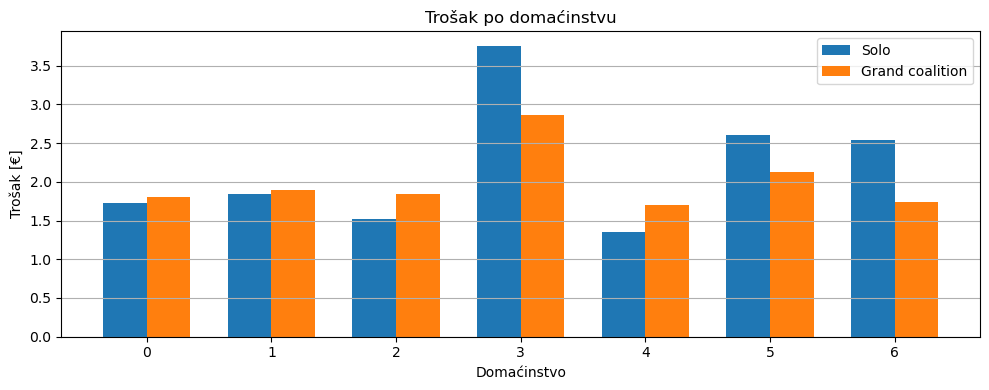

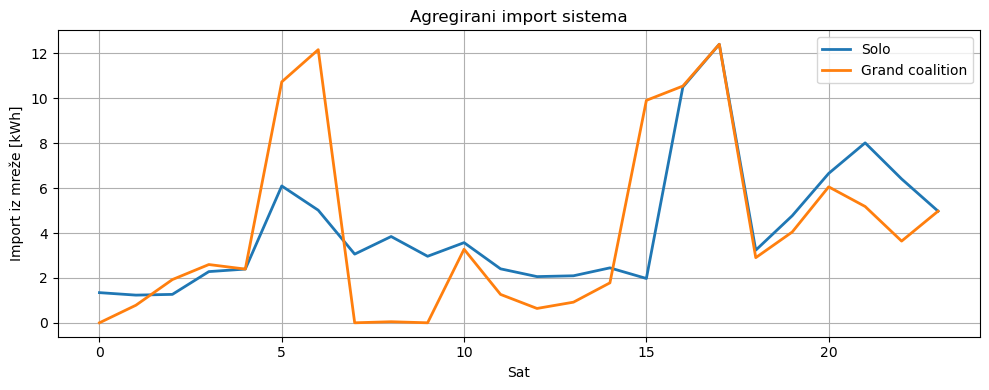

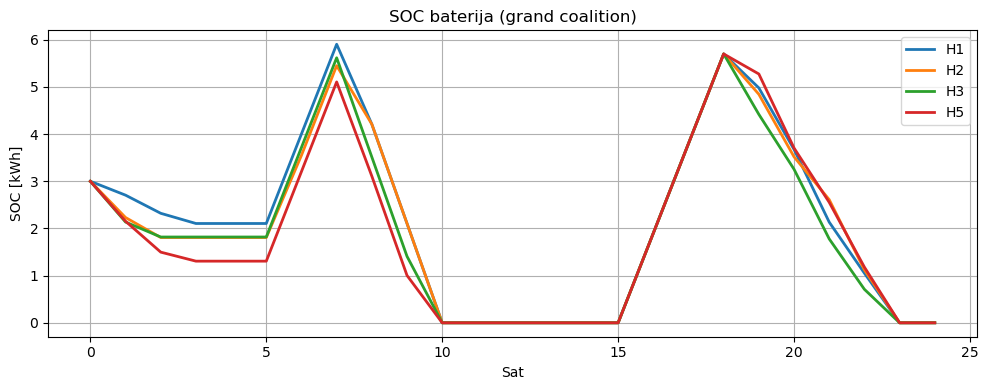

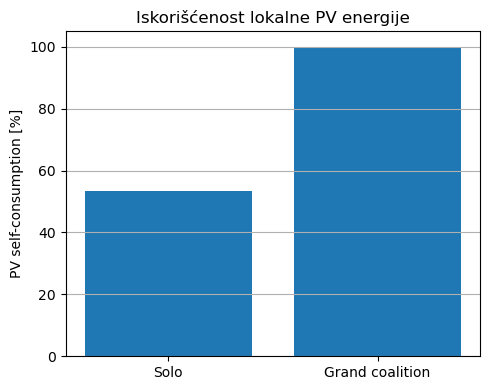

In [252]:
# =========================
# DINAMIČKI DASHBOARD
# =========================

# --- 1 Trošak po domaćinstvu ---
houses = players

cost_solo = np.array([C_solo_dyn[i] for i in houses])
cost_coal = np.array([grand_dyn["cost_per_house"][i] for i in houses])

plt.figure(figsize=(10,4))

x = np.arange(len(houses))
width = 0.35

plt.bar(x - width/2, cost_solo, width, label="Solo")
plt.bar(x + width/2, cost_coal, width, label="Grand coalition")

plt.xlabel("Domaćinstvo")
plt.ylabel("Trošak [€]")
plt.title("Trošak po domaćinstvu")
plt.legend()
plt.grid(axis="y")

plt.tight_layout()
plt.show()


# --- 2 Agregirani import iz mreže ---
import_solo = np.zeros(T)
import_coal = np.zeros(T)

for i in players:
    import_solo += solo_dyn["logs"][i]["Import"]
    import_coal += grand_dyn["logs"][i]["Import"]

plt.figure(figsize=(10,4))

plt.plot(hours, import_solo, linewidth=2, label="Solo")
plt.plot(hours, import_coal, linewidth=2, label="Grand coalition")

plt.xlabel("Sat")
plt.ylabel("Import iz mreže [kWh]")
plt.title("Agregirani import sistema")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# --- 3 SOC baterija ---
houses_batt = [i for i in players if has_batt[i-1]]

if len(houses_batt) > 0:

    plt.figure(figsize=(10,4))

    for i in houses_batt[:min(6, len(houses_batt))]:
        plt.plot(
            np.arange(T+1),
            grand_dyn["logs"][i]["SOC"],
            linewidth=2,
            label=f"H{i}"
        )

    plt.xlabel("Sat")
    plt.ylabel("SOC [kWh]")
    plt.title("SOC baterija (grand coalition)")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


# --- 4 PV self-consumption ---
pv_total = np.sum(G)

export_solo = 0
export_coal = 0

for i in players:
    export_solo += np.sum(solo_dyn["logs"][i]["Export"])
    export_coal += np.sum(grand_dyn["logs"][i]["Export"])

self_solo = pv_total - export_solo
self_coal = pv_total - export_coal

labels = ["Solo", "Grand coalition"]
values = [self_solo/pv_total*100, self_coal/pv_total*100]

plt.figure(figsize=(5,4))

plt.bar(labels, values)

plt.ylabel("PV self-consumption [%]")
plt.title("Iskorišćenost lokalne PV energije")
plt.grid(axis="y")

plt.tight_layout()
plt.show()

In [253]:
# =========================
# SHAPLEY UŠTEDA UNUTAR JEDNE KOALICIJE
# =========================

def shapley_on_subset(S, v_map):
    """
    Shapley raspodela za subigru definisanu na koaliciji S.
    Koristi v_map[T] za sve T ⊆ S.
    """
    members = sorted(S)
    m = len(members)

    phi = {i: 0.0 for i in members}
    fact = math.factorial(m)

    for pi in itertools.permutations(members):
        Tset = frozenset()
        for i in pi:
            before = Tset
            after = frozenset(set(Tset) | {i})
            v_before = v_map.get(before, 0.0)
            v_after = v_map.get(after, 0.0)
            phi[i] += (v_after - v_before)
            Tset = after

    for i in members:
        phi[i] /= fact

    return phi

In [254]:
# =========================
# SVE PARTICIJE SKUPA IGRAČA (za mali n)
# =========================

def partitions(lst):
    """
    Generiše sve particije liste lst.
    Svaka particija je lista blokova (tuple).
    """
    if len(lst) == 0:
        yield []
        return

    first = lst[0]
    for rest in partitions(lst[1:]):
        # first kao novi blok
        yield [(first,)] + rest

        # first ubaci u postojeći blok
        for i in range(len(rest)):
            yield rest[:i] + [tuple(sorted(rest[i] + (first,)))] + rest[i+1:]


def canonical_partition(part):
    """
    Kanonski zapis particije radi lakšeg poređenja.
    """
    blocks = [tuple(sorted(b)) for b in part]
    blocks.sort(key=lambda b: (len(b), b))
    return tuple(blocks)

In [255]:
# =========================
# PAYOFF U PARTICIJI
# =========================

def find_block(partition, i):
    for b in partition:
        if i in b:
            return b
    raise ValueError(f"Igrač {i} nije pronađen u particiji.")


def partition_value(partition, v_map):
    """
    Ukupna vrednost particije = zbir vrednosti blokova.
    """
    return sum(v_map.get(frozenset(b), 0.0) for b in partition)


def payoff_in_partition(partition, i, v_map):
    """
    Ušteda igrača i u datoj particiji,
    gde se u njegovom bloku koristi Shapley raspodela.
    """
    block = find_block(partition, i)
    S = frozenset(block)
    phiS = shapley_on_subset(S, v_map)
    return phiS[i]

In [259]:
# =========================
# NASH-STABILNA PARTICIJA
# =========================

def is_nash_stable(partition, v_map, players):
    """
    Particija je Nash-stabilna ako nijedan igrač ne može
    jednostrano da pređe u drugi blok ili da bude sam
    i time poveća svoj payoff.
    """
    blocks = [tuple(sorted(b)) for b in partition]

    for i in players:
        current_payoff = payoff_in_partition(blocks, i, v_map)
        current_block = find_block(blocks, i)

        # opcija 1: igrač ide u singleton
        if current_block != (i,):
            new_partition = [b for b in blocks if b != current_block]

            reduced_block = tuple(x for x in current_block if x != i)
            if len(reduced_block) > 0:
                new_partition.append(reduced_block)

            new_partition.append((i,))
            alt_payoff = payoff_in_partition(new_partition, i, v_map)

            if alt_payoff > current_payoff + 1e-9:
                return False

        # opcija 2: prelazak u drugi postojeći blok
        for target_block in blocks:
            if target_block == current_block:
                continue

            new_partition = [b for b in blocks if b not in (current_block, target_block)]

            reduced_block = tuple(x for x in current_block if x != i)
            if len(reduced_block) > 0:
                new_partition.append(reduced_block)

            expanded_block = tuple(sorted(target_block + (i,)))
            new_partition.append(expanded_block)

            alt_payoff = payoff_in_partition(new_partition, i, v_map)

            if alt_payoff > current_payoff + 1e-9:
                return False

    return True

In [263]:
# =========================
# SVE NASH-STABILNE PARTICIJE ZA MALI SCENARIO
# =========================

players_small = players[:5]   # možeš promeniti na 6 ako želiš

# napravi v_map za mali scenario iz postojećeg dinamičkog v_dyn
# zadržavamo samo koalicije koje su podskup players_small
v_small = {frozenset(): 0.0}

for S in dyn_coalitions:
    if set(S).issubset(set(players_small)):
        v_small[frozenset(S)] = v_dyn[S]

# proveri da li imamo sve potrebne koalicije za mali scenario
missing = []
for r in range(1, len(players_small)+1):
    for comb in itertools.combinations(players_small, r):
        if frozenset(comb) not in v_small:
            missing.append(frozenset(comb))

print("Broj nedostajućih koalicija za mali scenario:", len(missing))
if len(missing) > 0:
    print("Nedostaju koalicije, pa za players_small koristi manji skup koji je potpuno pokriven.")

Broj nedostajućih koalicija za mali scenario: 0


In [264]:
# =========================
# IZRAČUNAVANJE STABILNIH PARTICIJA
# =========================

all_parts = set()

for p in partitions(list(players_small)):
    all_parts.add(canonical_partition(p))

all_parts = [list(p) for p in sorted(all_parts, key=lambda P: (len(P), P))]

stable_parts = []
for P in all_parts:
    if is_nash_stable(P, v_small, players_small):
        stable_parts.append(P)

print("Ukupno particija:", len(all_parts))
print("Broj Nash-stabilnih particija:", len(stable_parts))

Ukupno particija: 52
Broj Nash-stabilnih particija: 1


In [265]:
# =========================
# TABELA STABILNIH PARTICIJA
# =========================

rows = []

for P in stable_parts:
    part_str = " | ".join("{" + ",".join(map(str, b)) + "}" for b in P)
    total_val = partition_value(P, v_small)

    rows.append({
        "Partition": part_str,
        "Broj koalicija": len(P),
        "Ukupna vrednost Σ v(S)": total_val
    })

df_stable_parts = pd.DataFrame(rows).sort_values("Ukupna vrednost Σ v(S)", ascending=False)
df_stable_parts

,Partition,Broj koalicija,Ukupna vrednost Σ v(S)
0,"{5} | {1,2,3,4}",2,0.526269


In [266]:
# =========================
# NAJBOLJA STABILNA PARTICIJA
# =========================

if len(stable_parts) == 0:
    print("Nema Nash-stabilnih particija za dati scenario.")
else:
    best_part = max(stable_parts, key=lambda P: partition_value(P, v_small))

    print("Najbolja stabilna particija:")
    print(" | ".join("{" + ",".join(map(str, b)) + "}" for b in best_part))
    print("Ukupna vrednost:", partition_value(best_part, v_small))

    # payoff po kući
    rows = []
    for i in players_small:
        rows.append({
            "House": i,
            "Coalition": coalition_str(frozenset(find_block(best_part, i))),
            "Savings x_i": payoff_in_partition(best_part, i, v_small)
        })

    df_best_part = pd.DataFrame(rows)
    df_best_part

Najbolja stabilna particija:
{5} | {1,2,3,4}
Ukupna vrednost: 0.5262691002179309


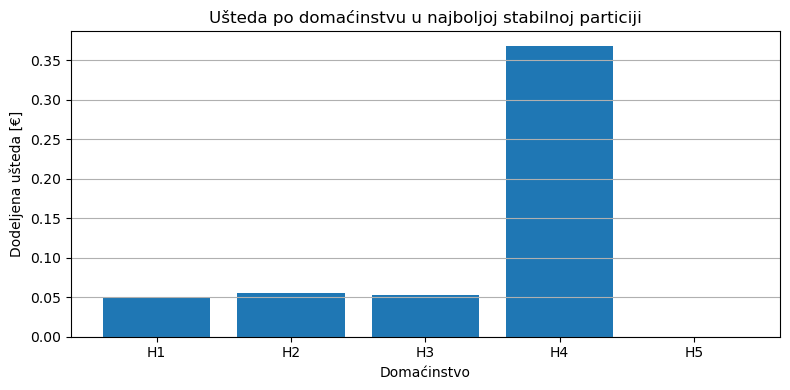

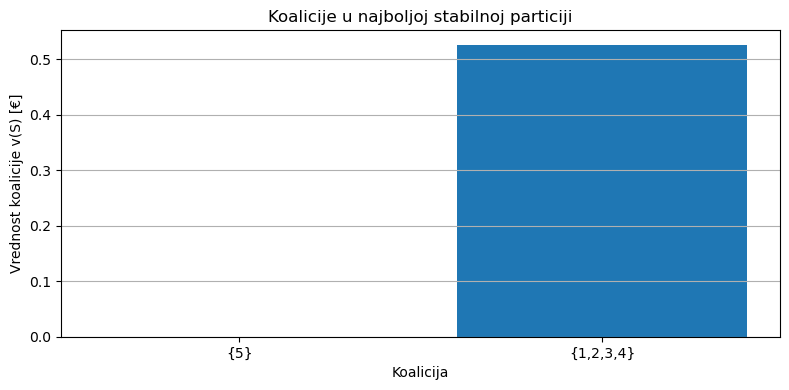

In [267]:
# =========================
# GRAFIČKI PRIKAZ NAJBOLJE STABILNE PARTICIJE
# =========================

if len(stable_parts) > 0:
    coalition_labels = [coalition_str(frozenset(find_block(best_part, i))) for i in players_small]
    savings_vals = [payoff_in_partition(best_part, i, v_small) for i in players_small]

    plt.figure(figsize=(8,4))
    plt.bar([f"H{i}" for i in players_small], savings_vals)
    plt.xlabel("Domaćinstvo")
    plt.ylabel("Dodeljena ušteda [€]")
    plt.title("Ušteda po domaćinstvu u najboljoj stabilnoj particiji")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))
    block_values = []
    block_names = []

    for b in best_part:
        S = frozenset(b)
        block_names.append(coalition_str(S))
        block_values.append(v_small[S])

    plt.bar(block_names, block_values)
    plt.xlabel("Koalicija")
    plt.ylabel("Vrednost koalicije v(S) [€]")
    plt.title("Koalicije u najboljoj stabilnoj particiji")
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()